[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/evinracher/3008338-geospatial-analysis/blob/main/project/house-price-medellin.ipynb)

# Introduccción

En este notebook se presenta el desarrollo de un proyecto para predecir el precio de las viviendas en Medellín. Se presenta una comparación de diferentes modelos espaciales, entrenados en un dataset disponible en Kaggle, que recopila la información de varias viviendas en Colombia. Adicionalmente se presenta una comparación con modelos de machine learning tradicionales. El dataset incluye información como número de habitaciones, número de baños, área total del inmueble y precio.

Para realizar este proyecto, se filtró la información solo de los inmuebles ubicados en Medellín y se hizo el procesamiento de datos adecuado para filtrar registros con información faltante o datos errados.


Dataset principal: https://www.kaggle.com/datasets/julianusugaortiz/colombia-housing-properties-price

In [598]:
%matplotlib inline
# needed in jupyter notebook
import matplotlib.pyplot as plt

# Carga de datos

Se cargan los datos desde Kaggle directamente, usando la API de Kaggle

In [599]:
# Instalando las dependencias necesarias
%pip install kagglehub scikit-learn


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [600]:
# Requires libomp: On Mac, you can install it running: brew install libomp
%pip install xgboost


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [601]:
from pathlib import Path

import kagglehub
import pandas as pd

# Download latest version
dataset_path = Path(
    kagglehub.dataset_download("julianusugaortiz/colombia-housing-properties-price")
)

print("Path to dataset files:", dataset_path)

# Find and load the CSV file
csv_files = list(dataset_path.glob("*.csv"))
print("CSV files:", [file.name for file in csv_files])

csv_path = dataset_path / "co_properties.csv"
df = pd.read_csv(csv_path)

df.head()

Path to dataset files: /Users/kevin.parra/.cache/kagglehub/datasets/julianusugaortiz/colombia-housing-properties-price/versions/2
CSV files: ['co_properties.csv']


,id,ad_type,start_date,end_date,created_on,lat,lon,l1,l2,l3,...,bathrooms,surface_total,surface_covered,price,currency,price_period,title,description,property_type,operation_type
0,KsjahK62rxcYKXXQjOdkqw==,Propiedad,2020-10-07,2021-10-09,2020-10-07,3.9210,-76.506000,Colombia,Valle del Cauca,NaN,...,7.0,NaN,NaN,1.300000e+09,COP,NaN,Casa Campestre en venta en darien 3469064,"HERMOSA CASA CAMPESTRE, &Aacute;REA 6,000 MT, ...",Casa,Venta
1,Y+gsBZYq1zu5NoR3V5oUGA==,Propiedad,2020-10-07,2021-01-06,2020-10-07,3.3577,-76.541811,Colombia,Valle del Cauca,Cali,...,7.0,NaN,NaN,2.800000e+09,COP,NaN,Casa en ciudsd jardin,Casa independiente con posiciona en ciudad jar...,Casa,Venta
2,Jpzqxj8/Vgf3Aa5ASxUBNg==,Propiedad,2020-10-07,2020-10-07,2020-10-07,3.3577,-76.541811,Colombia,Valle del Cauca,Cali,...,7.0,NaN,NaN,2.800000e+09,COP,Mensual,Casa en ciudsd jardin,Casa independiente con posiciona en ciudad jar...,Casa,Venta
3,ieuFnkFx/yHDD66iMV14Gw==,Propiedad,2020-10-07,2021-04-12,2020-10-07,3.3640,-76.538000,Colombia,Valle del Cauca,Cali,...,8.0,NaN,NaN,3.500000e+09,COP,NaN,Casa en venta en pance 1630426,"EXCELENTE CASA - LOTE 6,373 MT, EN OBRA GRIS U...",Casa,Venta
4,g4u5JM+hAHEk8SukRSjMzg==,Propiedad,2020-10-07,9999-12-31,2020-10-07,3.3910,-76.517000,Colombia,Valle del Cauca,Cali,...,9.0,NaN,NaN,4.800000e+08,COP,NaN,CASA EXTERNA BARRIO CIUDAD 2000,"CASA EXTERNA EN EL BARRIO CIUDAD 2000,CONSTRUI...",Casa,Venta


# Procesamiento y exploración de los datos

El dataset tiene varias características que no son importantes para el problema, como la columna l1, que representa el país donde está ubicado el inmueble y para la cual todos los registros tienen el valor de "Colombia". Así mismo, ad_type, que tiene el mismo valor para todos los registros y no aporta ningún valor a los modelos.

Por lo tanto, se van a eliminar esas columnas

In [602]:
columns_to_keep = [
    "lat",
    "lon",
    "l3",
    "l4",
    "l5",
    "l6",
    "rooms",
    "bedrooms",
    "bathrooms",
    "surface_total",
    "surface_covered",
    "price",
    "title",
    "property_type",
    "operation_type",
]

discarded_columns = [col for col in df.columns if col not in columns_to_keep]

df_selected = df[columns_to_keep].copy()

print("Discarded columns:")
print(discarded_columns)

df_selected.head()

Discarded columns:
['id', 'ad_type', 'start_date', 'end_date', 'created_on', 'l1', 'l2', 'currency', 'price_period', 'description']


,lat,lon,l3,l4,l5,l6,rooms,bedrooms,bathrooms,surface_total,surface_covered,price,title,property_type,operation_type
0,3.9210,-76.506000,NaN,NaN,NaN,NaN,NaN,6.0,7.0,NaN,NaN,1.300000e+09,Casa Campestre en venta en darien 3469064,Casa,Venta
1,3.3577,-76.541811,Cali,Ciudad Jardín,NaN,NaN,NaN,NaN,7.0,NaN,NaN,2.800000e+09,Casa en ciudsd jardin,Casa,Venta
2,3.3577,-76.541811,Cali,Ciudad Jardín,NaN,NaN,NaN,NaN,7.0,NaN,NaN,2.800000e+09,Casa en ciudsd jardin,Casa,Venta
3,3.3640,-76.538000,Cali,Ciudad Jardín,NaN,NaN,NaN,5.0,8.0,NaN,NaN,3.500000e+09,Casa en venta en pance 1630426,Casa,Venta
4,3.3910,-76.517000,Cali,NaN,NaN,NaN,NaN,8.0,9.0,NaN,NaN,4.800000e+08,CASA EXTERNA BARRIO CIUDAD 2000,Casa,Venta


A continuación se presenta el significado de algunas columnas:

l1: País

l2: Departamento

l3: Cuidad

l4: Zona

l5: Localidad

l6: Barrio (Neighborhood)

Vamos a explorar los valores de estas columnas y ver si nos pueden aportar algo o por el contrario las podemos eliminar, recordando que se utilizarán solo los datos de inmuebles en Medellín

In [603]:
for col in ["l3", "l4", "l5", "l6"]:
    print(f"\nUnique values in {col}:")
    print(df_selected[col].dropna().unique())
    print(f"Total unique values: {df_selected[col].nunique(dropna=True)}")


Unique values in l3:
<StringArray>
[                'Cali',                 'Chía',                'Dagua',
              'Pereira',              'Jamundí',             'Restrepo',
            'Manizales',             'Medellín',           'Bogotá D.C',
          'Santa Marta',
 ...
              'Quipile', 'El Carmen de Bolívar',              'Caqueza',
           'Caicedonia',              'Fúquene',              'Buesaco',
              'Yaguará',          'Nuevo Colón',               'Sotara',
                'Ataco']
Length: 343, dtype: str
Total unique values: 343

Unique values in l4:
<StringArray>
[         'Ciudad Jardín',     'San Fernando Nuevo',               'Laureles',
     'Zona Noroccidental',        'Zona Occidental',         'Zona Chapinero',
                  'Caney',                   'Lili',        'Doce de Octubre',
             'La América',                  'Belén',             'El Poblado',
          'Villa Hermosa',             'Zona Norte',     'Zona Surocci

Sin duda estas columnas tienen bastantes valores únicos, representando diferentes barrios y localidades.

## Filtrando los datos de solo Medellín

Sin embargo, nuestro interés es filtrar solo la información de Medellín, vamos a filtrar el dataset para obtener solo los datos que nos interesan.

In [604]:
df_medellin = df_selected[df_selected["l3"] == "Medellín"].copy()

print("Medellín dataset shape:", df_medellin.shape)

df_medellin.head()

Medellín dataset shape: (262856, 15)


,lat,lon,l3,l4,l5,l6,rooms,bedrooms,bathrooms,surface_total,surface_covered,price,title,property_type,operation_type
46,NaN,NaN,Medellín,NaN,NaN,NaN,NaN,NaN,8.0,NaN,NaN,4.000000e+09,Casa en Venta Ubicado en MEDELLIN,Casa,Venta
47,6.238637,-75.602011,Medellín,Laureles,NaN,NaN,NaN,19.0,20.0,NaN,NaN,1.300000e+07,"CASA EN ARRIENDO, MEDELLIN-LAURELES",Casa,Arriendo
48,NaN,NaN,Medellín,NaN,NaN,NaN,NaN,NaN,7.0,NaN,NaN,1.500000e+07,Casa en Arriendo Ubicado en MEDELLIN,Casa,Arriendo
157,6.297802,-75.577835,Medellín,Doce de Octubre,NaN,NaN,5.0,5.0,NaN,NaN,NaN,3.100000e+08,Venta de casa en Florencia,Casa,Venta
158,6.245972,-75.614730,Medellín,La América,NaN,NaN,7.0,7.0,NaN,NaN,NaN,2.500000e+06,Arriendo Casa Duplex en Santa Monica,Casa,Arriendo


In [605]:
for col in ["l4", "l5", "l6"]:
    print(f"\nUnique values in {col}:")
    print(df_medellin[col].unique())
    print(f"Total unique values: {df_medellin[col].nunique()}")


Unique values in l4:
<StringArray>
[                   nan,             'Laureles',      'Doce de Octubre',
           'La América',                'Belén',           'El Poblado',
        'Villa Hermosa',              'Robledo',             'Castilla',
           'San Javier',        'San Cristóbal',           'Santa Cruz',
          'Santa Elena',             'Guayabal',             'Aranjuez',
           'Candelaria',            'Altavista',             'Manrique',
         'Buenos Aires',              'Popular', 'San Antonio de Prado',
             'Palmitas']
Length: 22, dtype: str
Total unique values: 21

Unique values in l5:
<StringArray>
[nan]
Length: 1, dtype: str
Total unique values: 0

Unique values in l6:
<StringArray>
[nan]
Length: 1, dtype: str
Total unique values: 0


Vemos que para Medellín, las columnas l5 y l6 no tienen ningún valor representativo, por tanto vamos a eliminarlas.

In [606]:
df_medellin = df_medellin.drop(columns=["l5", "l6"])

print("Medellín dataset shape after dropping l5 and l6:", df_medellin.shape)
print("Remaining columns:")
print(df_medellin.columns.tolist())

df_medellin.head()

Medellín dataset shape after dropping l5 and l6: (262856, 13)
Remaining columns:
['lat', 'lon', 'l3', 'l4', 'rooms', 'bedrooms', 'bathrooms', 'surface_total', 'surface_covered', 'price', 'title', 'property_type', 'operation_type']


,lat,lon,l3,l4,rooms,bedrooms,bathrooms,surface_total,surface_covered,price,title,property_type,operation_type
46,NaN,NaN,Medellín,NaN,NaN,NaN,8.0,NaN,NaN,4.000000e+09,Casa en Venta Ubicado en MEDELLIN,Casa,Venta
47,6.238637,-75.602011,Medellín,Laureles,NaN,19.0,20.0,NaN,NaN,1.300000e+07,"CASA EN ARRIENDO, MEDELLIN-LAURELES",Casa,Arriendo
48,NaN,NaN,Medellín,NaN,NaN,NaN,7.0,NaN,NaN,1.500000e+07,Casa en Arriendo Ubicado en MEDELLIN,Casa,Arriendo
157,6.297802,-75.577835,Medellín,Doce de Octubre,5.0,5.0,NaN,NaN,NaN,3.100000e+08,Venta de casa en Florencia,Casa,Venta
158,6.245972,-75.614730,Medellín,La América,7.0,7.0,NaN,NaN,NaN,2.500000e+06,Arriendo Casa Duplex en Santa Monica,Casa,Arriendo


In [607]:
print("Operation types")
print(df_medellin["operation_type"].dropna().unique())

Operation types
<StringArray>
['Venta', 'Arriendo', 'Arriendo temporal']
Length: 3, dtype: str


In [608]:
# Cantidad de registros por tipo de operación
print("\nRecords by operation type")
print(df_medellin["operation_type"].value_counts(dropna=False))


Records by operation type
operation_type
Arriendo             143439
Venta                119394
Arriendo temporal        23
Name: count, dtype: int64


In [609]:
print(df_medellin["property_type"].unique())

<StringArray>
[           'Casa',            'Lote',            'Otro',         'Oficina',
     'Apartamento', 'Local comercial',           'Finca',        'Depósito',
     'Parqueadero']
Length: 9, dtype: str


Así mismo, vemos que hay dos tipos de operaciones en el dataset: Venta y arriendo. En este proyecto nos enfocaremos solo en el precio de venta de un inmueble. Por tanto, vamos a filtrar solo por este tipo de operación

In [610]:
df_medellin = df_medellin[df_medellin["operation_type"] == "Venta"].copy()

df_medellin.drop(columns=["operation_type"], inplace=True)

Eliminamos adicionalmente otras columnas cuyos valores se repiten (en este caso, l3 que representa la ciudad y para nuestro subconjunto es la misma, Medellín); así mismo eliminamos columnas que no aportan mucho valor a nuestro problema:

In [611]:
df_medellin_clean = df_medellin.drop(columns=["l3", "title"]).copy()

In [612]:
df_medellin_clean.describe()

,lat,lon,rooms,bedrooms,bathrooms,surface_total,surface_covered,price
count,36540.000000,36540.000000,11889.000000,20456.000000,102697.000000,1356.000000,1442.000000,1.193700e+05
mean,6.214631,-75.561639,3.097906,2.995991,2.477677,498.648968,323.671290,5.644555e+08
std,1.130376,1.162069,1.300625,1.316010,1.290765,3172.582247,2902.863675,1.732681e+09
min,-75.580770,-97.494152,1.000000,0.000000,1.000000,11.000000,1.000000,0.000000e+00
25%,6.204034,-75.597782,3.000000,3.000000,2.000000,74.000000,74.000000,2.400000e+08
50%,6.228191,-75.577156,3.000000,3.000000,2.000000,120.000000,120.000000,3.450000e+08
75%,6.251000,-75.564960,3.000000,3.000000,3.000000,206.250000,200.000000,6.000000e+08
max,51.801231,14.154488,31.000000,41.000000,20.000000,83333.000000,105372.000000,4.650000e+11


In [613]:
df_medellin_clean.info()

<class 'pandas.DataFrame'>
Index: 119394 entries, 46 to 999044
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   lat              36540 non-null   float64
 1   lon              36540 non-null   float64
 2   l4               36417 non-null   str    
 3   rooms            11889 non-null   float64
 4   bedrooms         20456 non-null   float64
 5   bathrooms        102697 non-null  float64
 6   surface_total    1356 non-null    float64
 7   surface_covered  1442 non-null    float64
 8   price            119370 non-null  float64
 9   property_type    119394 non-null  str    
dtypes: float64(8), str(2)
memory usage: 10.0 MB


Mirando la información de las columnas, vemos que la mayoría tiene valores nulos para lat y lon y las demás variables.

In [614]:
df_medellin_clean = df_medellin_clean[df_medellin_clean["lat"].notna()].copy()
df_medellin_clean.head()

,lat,lon,l4,rooms,bedrooms,bathrooms,surface_total,surface_covered,price,property_type
157,6.297802,-75.577835,Doce de Octubre,5.0,5.0,NaN,NaN,NaN,3.100000e+08,Casa
160,6.307000,-75.579002,Doce de Octubre,NaN,NaN,NaN,NaN,NaN,1.500000e+08,Casa
161,6.201145,-75.565205,El Poblado,3.0,3.0,NaN,NaN,NaN,1.250000e+09,Casa
162,6.256467,-75.557640,Villa Hermosa,6.0,6.0,NaN,NaN,NaN,1.800000e+08,Casa
345,6.259253,-75.628381,San Javier,NaN,NaN,1.0,NaN,NaN,3.800000e+07,Casa


Vemos que para ciertos features como surface_covered, lat, y lon, el valor no se tiene el valor disponible. Más adelante se tratatará ese caso, por ahora separemos los datos.

In [615]:
# Renombramos L4
df_medellin_clean.rename(columns={"l4": "neighborhood"}, inplace=True)

Por último, miremos si hay registros que no tengan el precio asignado

In [616]:
df_medellin_clean["price"][df_medellin["price"].isna()]

122402   NaN
176430   NaN
228065   NaN
228725   NaN
229994   NaN
240100   NaN
297577   NaN
299789   NaN
299979   NaN
304090   NaN
315120   NaN
333004   NaN
394965   NaN
502051   NaN
537055   NaN
772402   NaN
Name: price, dtype: float64

Son pocos registros, por lo tanto, se eliminarán estos registros para evitar errores en el entrenamiento:

In [617]:
df_medellin_clean = df_medellin_clean[df_medellin_clean["price"].notna()].copy()

In [618]:
df_medellin_clean.info()

<class 'pandas.DataFrame'>
Index: 36524 entries, 157 to 999044
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   lat              36524 non-null  float64
 1   lon              36524 non-null  float64
 2   neighborhood     35936 non-null  str    
 3   rooms            11795 non-null  float64
 4   bedrooms         19199 non-null  float64
 5   bathrooms        24974 non-null  float64
 6   surface_total    1311 non-null   float64
 7   surface_covered  1392 non-null   float64
 8   price            36524 non-null  float64
 9   property_type    36524 non-null  str    
dtypes: float64(8), str(2)
memory usage: 3.1 MB


Guardamos el dataset con las modificaciones hechas en un archivo .csv y lo cargamos nuevamente, esto con el fin de facilitar el flujo de trabajo y la reproducibilidad de este notebook:

In [619]:
from pathlib import Path

dataset_dir = Path("dataset")
dataset_dir.mkdir(exist_ok=True)

output_path = dataset_dir / "final_dataset.csv"
df_medellin_clean.to_csv(output_path, index=False)

print(f"Saved df_medellin to: {output_path}")

Saved df_medellin to: dataset/final_dataset.csv


In [620]:
import pandas as pd
df_medellin_clean = pd.read_csv("./dataset/final_dataset.csv")
df_medellin_clean.head()

,lat,lon,neighborhood,rooms,bedrooms,bathrooms,surface_total,surface_covered,price,property_type
0,6.297802,-75.577835,Doce de Octubre,5.0,5.0,NaN,NaN,NaN,3.100000e+08,Casa
1,6.307000,-75.579002,Doce de Octubre,NaN,NaN,NaN,NaN,NaN,1.500000e+08,Casa
2,6.201145,-75.565205,El Poblado,3.0,3.0,NaN,NaN,NaN,1.250000e+09,Casa
3,6.256467,-75.557640,Villa Hermosa,6.0,6.0,NaN,NaN,NaN,1.800000e+08,Casa
4,6.259253,-75.628381,San Javier,NaN,NaN,1.0,NaN,NaN,3.800000e+07,Casa


In [621]:
df_medellin_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 36524 entries, 0 to 36523
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   lat              36524 non-null  float64
 1   lon              36524 non-null  float64
 2   neighborhood     35936 non-null  str    
 3   rooms            11795 non-null  float64
 4   bedrooms         19199 non-null  float64
 5   bathrooms        24974 non-null  float64
 6   surface_total    1311 non-null   float64
 7   surface_covered  1392 non-null   float64
 8   price            36524 non-null  float64
 9   property_type    36524 non-null  str    
dtypes: float64(8), str(2)
memory usage: 2.8 MB


Vamos a manejar los outliers en el precio, ya que hay valores muy altos, que se alejan de los demás valores para esta característica:

In [622]:
q99 = df_medellin_clean["price"].quantile(0.99)
df_medellin_clean = df_medellin_clean[df_medellin_clean["price"] <= q99].copy()

Así mismo, se deben manejar los valores bajos, pues vemos que hay un registros que tienen un precio muy bajo:

In [623]:
q01 = df_medellin_clean["price"].quantile(0.01)
df_medellin_clean = df_medellin_clean[df_medellin_clean["price"] >= q01].copy()

## Análisis final del dataset a utilizar

Una vez hechas todo el procesamiento pertinente de los datos, manejado los outliers, eliminado las columnas que no nos interesan para nuestro problema y demás filtros necesarios, hagamos un análisis y exploración final de los datos

In [624]:
df_medellin_clean.describe()

,lat,lon,rooms,bedrooms,bathrooms,surface_total,surface_covered,price
count,35814.000000,35814.000000,11700.000000,19006.000000,24568.000000,1275.000000,1358.000000,3.581400e+04
mean,6.221088,-75.568215,3.076667,2.983952,2.582628,387.253333,278.961708,5.948796e+08
std,0.862014,0.903975,1.162725,1.199186,1.277321,2785.493727,2915.710771,5.552808e+08
min,-75.580770,-97.494152,1.000000,0.000000,1.000000,11.000000,1.000000,8.200000e+07
25%,6.204034,-75.597856,3.000000,3.000000,2.000000,72.000000,73.000000,2.650000e+08
50%,6.228040,-75.577522,3.000000,3.000000,2.000000,118.000000,116.000000,4.200000e+08
75%,6.250822,-75.564953,3.000000,3.000000,3.000000,193.500000,190.000000,7.000000e+08
max,51.801231,14.154488,21.000000,35.000000,20.000000,83333.000000,105372.000000,4.200000e+09


In [625]:
info_df = pd.DataFrame({
    "Columna": df_medellin_clean.columns,
    "No nulos": df_medellin_clean.notnull().sum().values,
    "Nulos": df_medellin_clean.isnull().sum().values,
    "Tipo de dato": df_medellin_clean.dtypes.values
})

info_df

,Columna,No nulos,Nulos,Tipo de dato
0,lat,35814,0,float64
1,lon,35814,0,float64
2,neighborhood,35241,573,str
3,rooms,11700,24114,float64
4,bedrooms,19006,16808,float64
5,bathrooms,24568,11246,float64
6,surface_total,1275,34539,float64
7,surface_covered,1358,34456,float64
8,price,35814,0,float64
9,property_type,35814,0,str


In [626]:
df_medellin_clean.info()

<class 'pandas.DataFrame'>
Index: 35814 entries, 0 to 36523
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   lat              35814 non-null  float64
 1   lon              35814 non-null  float64
 2   neighborhood     35241 non-null  str    
 3   rooms            11700 non-null  float64
 4   bedrooms         19006 non-null  float64
 5   bathrooms        24568 non-null  float64
 6   surface_total    1275 non-null   float64
 7   surface_covered  1358 non-null   float64
 8   price            35814 non-null  float64
 9   property_type    35814 non-null  str    
dtypes: float64(8), str(2)
memory usage: 3.0 MB


Graficamos los datos por su ubicación, esto nos da una idea de la distribución espacial de los datos

<Axes: xlabel='lon', ylabel='lat'>

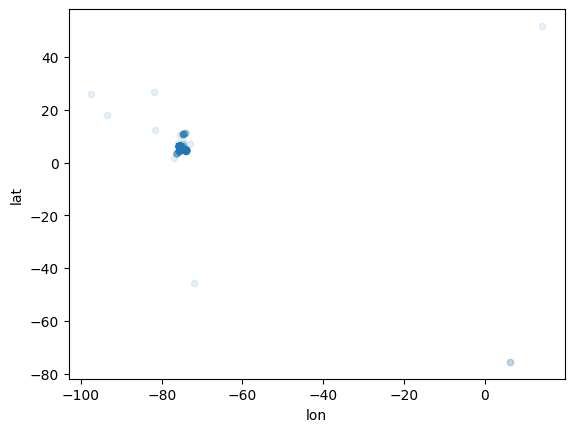

In [627]:
df_medellin_clean.plot(kind="scatter", x="lon", y="lat", alpha=0.1)

/var/folders/9r/f24wcwsd5lq1y7gwp439s8tm0000gn/T/ipykernel_84927/1320516810.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


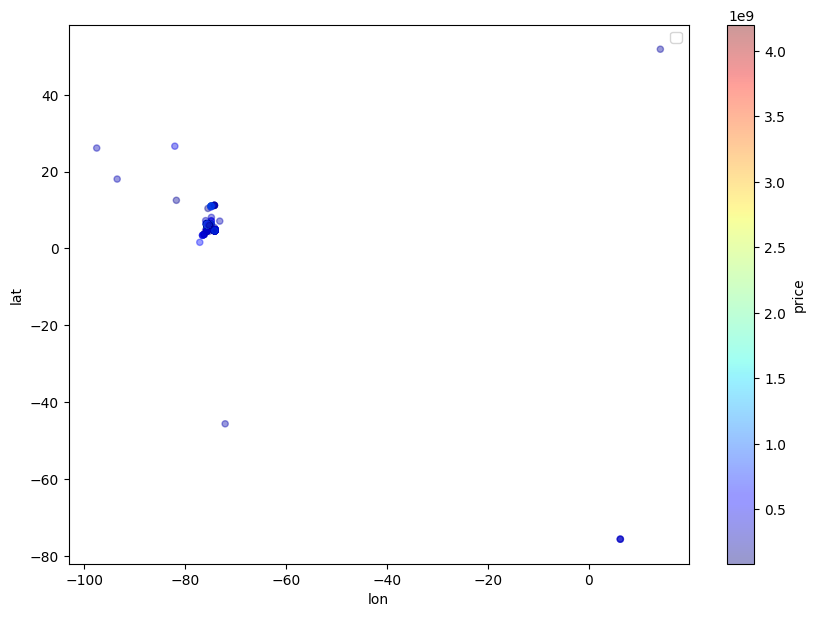

In [628]:
df_medellin_clean.plot(
    kind="scatter",
    x="lon",
    y="lat",
    alpha=0.4,
    figsize=(10, 7),
    c="price",
    cmap=plt.get_cmap("jet"),
    colorbar=True,
)
plt.legend()

## Buscando correlaciones

In [629]:
corr_matrix = df_medellin_clean.corr(numeric_only=True)
corr_matrix["price"].sort_values(ascending=False)

price              1.000000
bathrooms          0.674766
rooms              0.353544
bedrooms           0.259638
surface_total      0.111768
surface_covered    0.076278
lon                0.001399
lat               -0.008004
Name: price, dtype: float64

Vemos que las variables más correlacionadas son número de baños y area total:

array([[<Axes: xlabel='price', ylabel='price'>,
        <Axes: xlabel='bathrooms', ylabel='price'>,
        <Axes: xlabel='surface_total', ylabel='price'>,
        <Axes: xlabel='rooms', ylabel='price'>],
       [<Axes: xlabel='price', ylabel='bathrooms'>,
        <Axes: xlabel='bathrooms', ylabel='bathrooms'>,
        <Axes: xlabel='surface_total', ylabel='bathrooms'>,
        <Axes: xlabel='rooms', ylabel='bathrooms'>],
       [<Axes: xlabel='price', ylabel='surface_total'>,
        <Axes: xlabel='bathrooms', ylabel='surface_total'>,
        <Axes: xlabel='surface_total', ylabel='surface_total'>,
        <Axes: xlabel='rooms', ylabel='surface_total'>],
       [<Axes: xlabel='price', ylabel='rooms'>,
        <Axes: xlabel='bathrooms', ylabel='rooms'>,
        <Axes: xlabel='surface_total', ylabel='rooms'>,
        <Axes: xlabel='rooms', ylabel='rooms'>]], dtype=object)

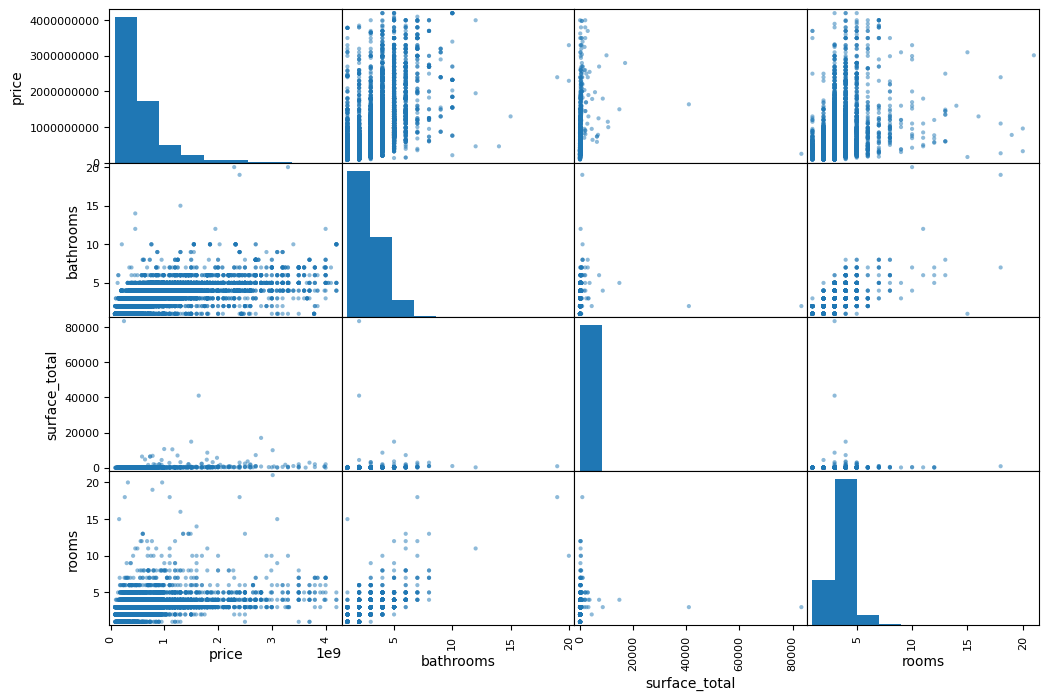

In [630]:
from pandas.plotting import scatter_matrix

attributes = [
    "price",
    "bathrooms",
    "surface_total",
    "rooms",
]
scatter_matrix(df_medellin_clean[attributes], figsize=(12, 8))

Veamos la gráfica de la variable más correlacionada por ahora:

<Axes: title={'center': 'Variable con mayor correlación'}, xlabel='bathrooms', ylabel='price'>

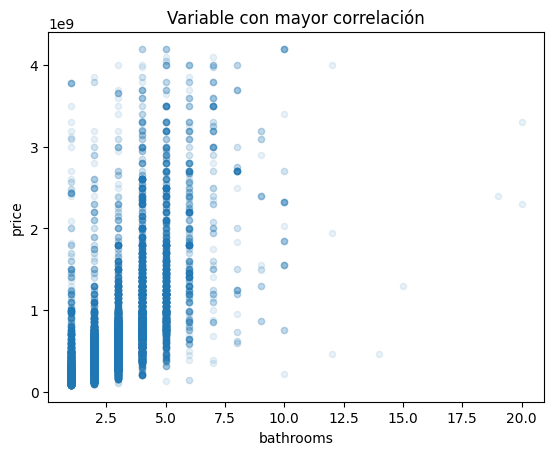

In [631]:
df_medellin_clean.plot(kind="scatter", x="bathrooms", y="price", alpha=0.1, title="Variable con mayor correlación")

Este análisis es para las variables númericas. Con las variables categoricas podemos hacer un histograma de frecuencias para ver que tanto se repite cada categoria

In [632]:
# Graficamos los 10 barrios más frecuentes para que sea legible
neighborhood_freq = df_medellin_clean["neighborhood"].fillna("Sin dato").value_counts().head(10).sort_values()
property_type_freq = df_medellin_clean["property_type"].fillna("Sin dato").value_counts()

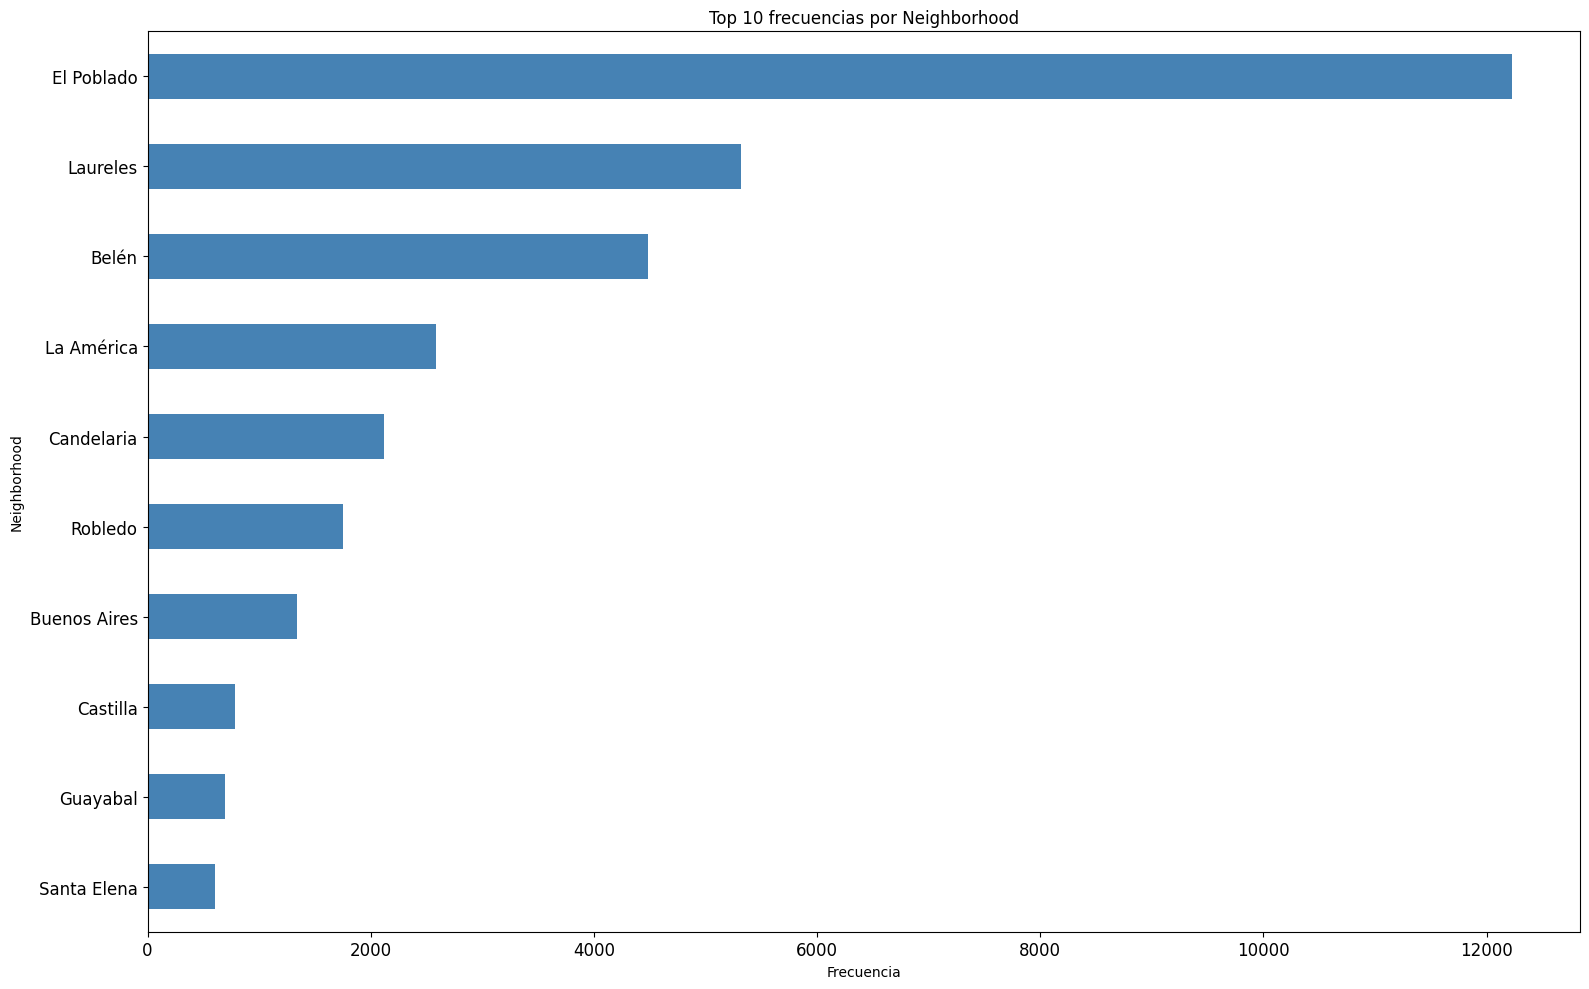

In [633]:
plt.figure(figsize=(16, 10))

neighborhood_freq.plot(
    kind="barh",
    color="steelblue",
    title="Top 10 frecuencias por Neighborhood",
)
plt.xlabel("Frecuencia")
plt.ylabel("Neighborhood")
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

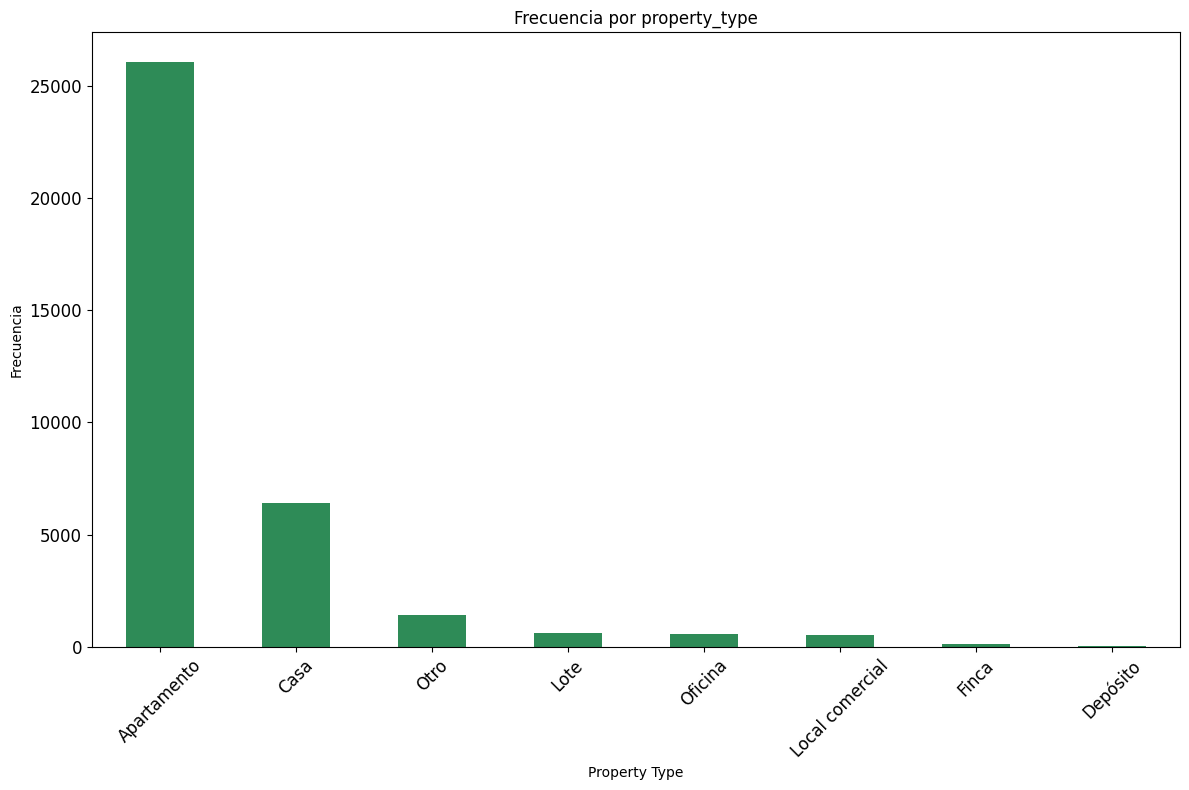

In [634]:
plt.figure(figsize=(12, 8))

property_type_freq.plot(
    kind="bar",
    color="seagreen",
    title="Frecuencia por property_type",
)
plt.xlabel("Property Type")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

# Entrenamiento

Una vez finalizado el procesamiento de datos, se utiliza `df_medellin_clean` como punto de partida y se divide una sola vez en entrenamiento y prueba. Todos los modelos se ajustan exclusivamente con entrenamiento y se evalúan con prueba.

In [635]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(
    df_medellin_clean,
    test_size=0.3,
    random_state=42,
)

print(f"Observaciones de entrenamiento: {len(train_set)}")
print(f"Observaciones de prueba: {len(test_set)}")

Observaciones de entrenamiento: 25069
Observaciones de prueba: 10745


In [636]:
train_set.head()

,lat,lon,neighborhood,rooms,bedrooms,bathrooms,surface_total,surface_covered,price,property_type
28776,6.212009,-75.559011,El Poblado,NaN,NaN,2.0,NaN,NaN,1.800000e+09,Oficina
4073,6.210000,-75.558000,El Poblado,NaN,3.0,4.0,NaN,NaN,7.100000e+08,Apartamento
10705,6.276607,-75.559693,Aranjuez,NaN,NaN,2.0,NaN,NaN,1.870000e+08,Casa
34244,6.282000,-75.561000,Aranjuez,2.0,2.0,1.0,65.0,65.0,1.400000e+08,Apartamento
6740,6.188863,-75.561118,El Poblado,4.0,4.0,NaN,NaN,NaN,8.900000e+08,Apartamento


Separamos los datos de la variable objetivo, en este caso precio

In [637]:
train_set.info()

<class 'pandas.DataFrame'>
Index: 25069 entries, 28776 to 16121
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   lat              25069 non-null  float64
 1   lon              25069 non-null  float64
 2   neighborhood     24649 non-null  str    
 3   rooms            8247 non-null   float64
 4   bedrooms         13371 non-null  float64
 5   bathrooms        17134 non-null  float64
 6   surface_total    897 non-null    float64
 7   surface_covered  948 non-null    float64
 8   price            25069 non-null  float64
 9   property_type    25069 non-null  str    
dtypes: float64(8), str(2)
memory usage: 2.1 MB


In [638]:
house_data = train_set.drop(columns=["price"])
target = train_set["price"].copy()

Usamos SimpleImputer para llenar los valores NaN de las variables numéricas, además, creamos un pipeline que se puede reutilizar en el momento de la evaluación. Adicionalmente, hacemos estandarización en los datos para evitar problemas con outliers y tener los datos escalados para el modelo. Esto para las variables numéricas:

In [639]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer


house_num_features = house_data.drop(["neighborhood", "property_type"], axis=1)

num_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("std_scaler", StandardScaler()),
    ]
)

Ahora procesamos las variables categóricas, en este caso tenemos property_type y neighborhood. Para ambas haremos OneHotEncoder ya que no son muchas las categorías disponibles

In [640]:
house_data = house_data.copy()

In [641]:
house_data

,lat,lon,neighborhood,rooms,bedrooms,bathrooms,surface_total,surface_covered,property_type
28776,6.212009,-75.559011,El Poblado,NaN,NaN,2.0,NaN,NaN,Oficina
4073,6.210000,-75.558000,El Poblado,NaN,3.0,4.0,NaN,NaN,Apartamento
10705,6.276607,-75.559693,Aranjuez,NaN,NaN,2.0,NaN,NaN,Casa
34244,6.282000,-75.561000,Aranjuez,2.0,2.0,1.0,65.0,65.0,Apartamento
6740,6.188863,-75.561118,El Poblado,4.0,4.0,NaN,NaN,NaN,Apartamento
...,...,...,...,...,...,...,...,...,...
17195,6.183168,-75.568113,El Poblado,NaN,NaN,6.0,NaN,NaN,Casa
6378,6.215963,-75.606627,Altavista,3.0,3.0,NaN,NaN,NaN,Apartamento
11499,6.225233,-75.565447,Candelaria,3.0,3.0,NaN,NaN,NaN,Apartamento
895,6.237220,-75.588056,Belén,4.0,4.0,NaN,NaN,NaN,Apartamento


In [642]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

num_attribs = list(house_num_features)
cat_attribs = ["neighborhood", "property_type"]

full_pipeline = ColumnTransformer(
    [
        ("num", num_pipeline, num_attribs),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(handle_unknown="ignore")),
            ]),
            cat_attribs,
        ),
    ]
)

Una vez preparado exclusivamente el conjunto de entrenamiento, se ajustan los modelos y se seleccionan sus hiperparámetros mediante validación cruzada dentro de ese mismo conjunto. Las métricas calculadas aquí son diagnósticos internos de entrenamiento; la comparación final se realiza únicamente sobre prueba.

## Random Forest


In [643]:
import numpy as np
from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

forest_reg = Pipeline(
    [
        ("preprocessor", clone(full_pipeline)),
        ("model", RandomForestRegressor(random_state=42, n_jobs=-1)),
    ]
)
forest_reg.fit(house_data, target)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

### Validación interna en entrenamiento

In [644]:
print("Random Forest base ajustado exclusivamente con datos de entrenamiento.")

Random Forest base ajustado exclusivamente con datos de entrenamiento.


**Usando cross-validation**

In [645]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    forest_reg,
    house_data,
    target,
    scoring="neg_mean_squared_error",
    cv=10,
    n_jobs=-1,
)
random_forest_rmse_scores = np.sqrt(-scores)

In [646]:
def display_scores(scores):
    print("Puntajes:", scores)
    print("Media:", scores.mean())
    print("Desviación estándar:", scores.std())

display_scores(random_forest_rmse_scores)

Puntajes: [3.23553878e+08 2.97430974e+08 3.14416864e+08 3.01041152e+08
 3.04043628e+08 2.84745822e+08 3.10090885e+08 3.01070818e+08
 3.13586571e+08 2.82548084e+08]
Media: 303252867.6784028
Desviación estándar: 12270620.607147833


La validación cruzada anterior vuelve a ajustar el preprocesamiento dentro de cada pliegue. Por tanto, cada pliegue de validación permanece separado de su correspondiente ajuste.

## XGBoost

In [647]:
from xgboost import XGBRegressor

r_xgboost = Pipeline(
    [
        ("preprocessor", clone(full_pipeline)),
        (
            "model",
            XGBRegressor(
                n_estimators=100,
                learning_rate=0.1,
                max_depth=3,
                random_state=42,
                objective="reg:squarederror",
                n_jobs=-1,
            ),
        ),
    ]
)
r_xgboost.fit(house_data, target)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

### Ajuste del modelo base

In [648]:
print("XGBoost base ajustado exclusivamente con datos de entrenamiento.")

XGBoost base ajustado exclusivamente con datos de entrenamiento.


## Optimizando los hiperparametros

A continuación se optimizan los hiperparámetros de Random Forest y XGBoost mediante GridSearchCV, que evalúa diferentes combinaciones y conserva la de mejor desempeño.

## Optimizando para Random Forest

In [649]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

random_forest_pipeline = Pipeline(
    [
        ("preprocessor", clone(full_pipeline)),
        ("model", RandomForestRegressor(random_state=42, n_jobs=-1)),
    ]
)
random_forest_param_grid = {
    "model__n_estimators": [50, 100],
    "model__max_depth": [None, 10],
    "model__max_features": ["sqrt", 0.5],
}

grid_search_random_forest = GridSearchCV(
    random_forest_pipeline,
    random_forest_param_grid,
    cv=3,
    scoring="neg_mean_squared_error",
    return_train_score=True,
    n_jobs=-1,
)
grid_search_random_forest.fit(house_data, target)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [None, 10], 'model__max_features': ['sqrt', 0.5], 'model__n_estimators': [50, 100]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and paramete

In [650]:
grid_search_random_forest.best_params_

{'model__max_depth': None,
 'model__max_features': 0.5,
 'model__n_estimators': 100}

In [651]:
best_params_random_forest = pd.DataFrame(
    grid_search_random_forest.best_params_.items(),
    columns=["Hiperparámetro", "Mejor valor"]
)

best_params_random_forest

,Hiperparámetro,Mejor valor
0,model__max_depth,NaN
1,model__max_features,0.5
2,model__n_estimators,100.0


Usando el mejor modelo encontrado:

In [652]:
best_random_forest = grid_search_random_forest.best_estimator_
best_random_forest

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

### Modelo seleccionado mediante validación cruzada

In [653]:
print("Random Forest optimizado seleccionado sin utilizar datos de prueba.")

Random Forest optimizado seleccionado sin utilizar datos de prueba.


## Optimización XGBoost

In [654]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

xgboost_pipeline = Pipeline(
    [
        ("preprocessor", clone(full_pipeline)),
        (
            "model",
            XGBRegressor(
                random_state=42,
                objective="reg:squarederror",
                n_jobs=-1,
            ),
        ),
    ]
)
xgboost_param_grid = {
    "model__n_estimators": [50, 100, 200],
    "model__max_depth": [2, 3, 4],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],
}

grid_search_xgboost = GridSearchCV(
    xgboost_pipeline,
    xgboost_param_grid,
    cv=3,
    scoring="neg_mean_squared_error",
    return_train_score=True,
    n_jobs=-1,
)
grid_search_xgboost.fit(house_data, target)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__colsample_bytree': [0.8, 1.0], 'model__learning_rate': [0.03, 0.05, ...], 'model__max_depth': [2, 3, ...], 'model__n_estimators': [50, 100, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messag

In [655]:
grid_search_xgboost.best_params_

{'model__colsample_bytree': 1.0,
 'model__learning_rate': 0.1,
 'model__max_depth': 4,
 'model__n_estimators': 200,
 'model__subsample': 0.8}

Usando el mejor modelo encontrado:

In [656]:
best_xgboost = grid_search_xgboost.best_estimator_
best_xgboost

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

### Modelo seleccionado mediante validación cruzada

In [657]:
print("XGBoost optimizado seleccionado sin utilizar datos de prueba.")

XGBoost optimizado seleccionado sin utilizar datos de prueba.


# Evaluación

Hasta ahora hemos entrenado y probado diferentes modelos en el data set de entrenamiento. Optimizamos los parámetros de los modelos usando Grid Search y tenemos ahora las mejores versiones de cada modelo. Vamos ahora a hacer la evaluación final usando el data set de test y comparar los resultados, tanto de los modelos base como de los optimizados

In [658]:
test_data = test_set.drop(columns=["price"]).copy()
test_target = test_set["price"].copy()

In [659]:
test_data.info()

<class 'pandas.DataFrame'>
Index: 10745 entries, 32240 to 35826
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   lat              10745 non-null  float64
 1   lon              10745 non-null  float64
 2   neighborhood     10592 non-null  str    
 3   rooms            3453 non-null   float64
 4   bedrooms         5635 non-null   float64
 5   bathrooms        7434 non-null   float64
 6   surface_total    378 non-null    float64
 7   surface_covered  410 non-null    float64
 8   property_type    10745 non-null  str    
dtypes: float64(7), str(2)
memory usage: 839.5 KB


## Modelos base

### Random Forest base

In [660]:
y_pred_test_random_forest = forest_reg.predict(test_data)

test_random_forest_mbe = mean_absolute_error(test_target, y_pred_test_random_forest)
test_random_forest_mse = mean_squared_error(test_target, y_pred_test_random_forest)
test_random_forest_rmse = np.sqrt(test_random_forest_mse)
test_random_forest_r2s = r2_score(test_target, y_pred_test_random_forest)

print("MAE:", test_random_forest_mbe)
print("MSE:", test_random_forest_mse)
print("RMSE:", test_random_forest_rmse)
print("R2_score:", test_random_forest_r2s)

MAE: 144701313.41477498
MSE: 8.961348685392366e+16
RMSE: 299355118.3025332
R2_score: 0.7041081895763259


### XGBoost base

In [661]:
y_pred_test_xgboost = r_xgboost.predict(test_data)

test_xgboost_mbe = mean_absolute_error(test_target, y_pred_test_xgboost)
test_xgboost_mse = mean_squared_error(test_target, y_pred_test_xgboost)
test_xgboost_rmse = np.sqrt(test_xgboost_mse)
test_xgboost_r2s = r2_score(test_target, y_pred_test_xgboost)

print("MAE:", test_xgboost_mbe)
print("MSE:", test_xgboost_mse)
print("RMSE:", test_xgboost_rmse)
print("R2_score:", test_xgboost_r2s)

MAE: 212685614.0186133
MSE: 1.3874224391806421e+17
RMSE: 372481199.4155735
R2_score: 0.5418915703829512


## Modelos optimizados

### Random Forest optimizado

In [662]:
y_pred_test_best_random_forest = best_random_forest.predict(test_data)

test_best_random_forest_mbe = mean_absolute_error(test_target, y_pred_test_best_random_forest)
test_best_random_forest_mse = mean_squared_error(test_target, y_pred_test_best_random_forest)
test_best_random_forest_rmse = np.sqrt(test_best_random_forest_mse)
test_best_random_forest_r2s = r2_score(test_target, y_pred_test_best_random_forest)

print("MAE:", test_best_random_forest_mbe)
print("MSE:", test_best_random_forest_mse)
print("RMSE:", test_best_random_forest_rmse)
print("R2_score:", test_best_random_forest_r2s)

MAE: 143795799.92850235
MSE: 8.725277825439984e+16
RMSE: 295385812.5475898
R2_score: 0.7119029352772098


### XGBoost optimizado

In [663]:
y_pred_test_best_xgboost = best_xgboost.predict(test_data)

test_best_xgboost_mbe = mean_absolute_error(test_target, y_pred_test_best_xgboost)
test_best_xgboost_mse = mean_squared_error(test_target, y_pred_test_best_xgboost)
test_best_xgboost_rmse = np.sqrt(test_best_xgboost_mse)
test_best_xgboost_r2s = r2_score(test_target, y_pred_test_best_xgboost)

print("MAE:", test_best_xgboost_mbe)
print("MSE:", test_best_xgboost_mse)
print("RMSE:", test_best_xgboost_rmse)
print("R2_score:", test_best_xgboost_r2s)

MAE: 198260252.47668684
MSE: 1.2187305247051787e+17
RMSE: 349103211.77342075
R2_score: 0.5975913960792159


## Resultados

A continuación vamos a analizar los resultados de nuestros modelos. Algo que podemos analizar es la importancia que tiene cada característica para el modelo, usando el modelo optimizado de Random Forest para esto:

Diez características más importantes:


,Característica,Importancia
4,num__bathrooms,0.253643
0,num__lat,0.220464
1,num__lon,0.213652
14,cat__neighborhood_El Poblado,0.071888
28,cat__property_type_Apartamento,0.040783
3,num__bedrooms,0.035587
2,num__rooms,0.029129
29,cat__property_type_Casa,0.023404
26,cat__neighborhood_Santa Elena,0.020544
5,num__surface_total,0.012831


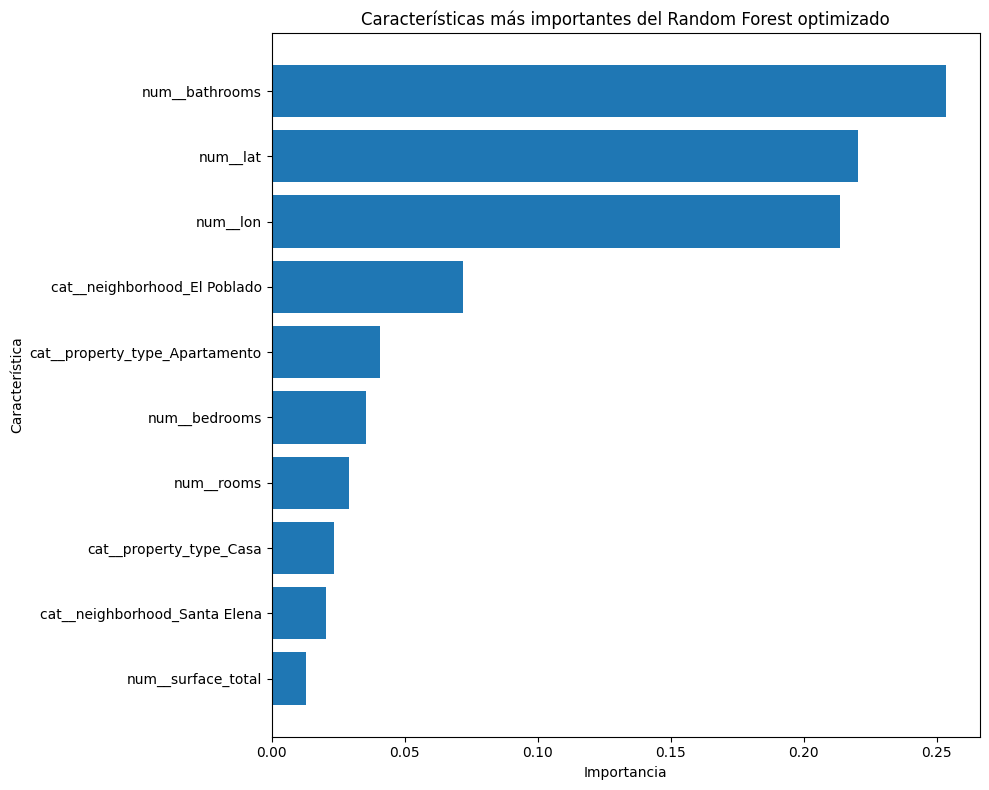

In [664]:
fitted_random_forest_preprocessor = best_random_forest.named_steps["preprocessor"]
fitted_random_forest_model = best_random_forest.named_steps["model"]
all_feature_names = fitted_random_forest_preprocessor.get_feature_names_out()

importance_df = pd.DataFrame(
    {
        "Característica": all_feature_names,
        "Importancia": fitted_random_forest_model.feature_importances_,
    }
).sort_values("Importancia", ascending=False)

print("Diez características más importantes:")
display(importance_df.head(10))

top_features = importance_df.head(10).sort_values("Importancia")
plt.figure(figsize=(10, 8))
plt.barh(top_features["Característica"], top_features["Importancia"])
plt.xlabel("Importancia")
plt.ylabel("Característica")
plt.title("Características más importantes del Random Forest optimizado")
plt.tight_layout()
plt.show()

Del resultado anterior, podemos confirmar que el número de baños es la caracteristica más importante y relacionada con el precio. Adicionalmente, vemos que la ubicación también es importante. Esto era algo que no mostraba la correlación. Incluso vemos que el hecho de que un inmueble esté ubicado en el poblado tiene una gran importancia en relación al precio.

Ahora vamos a comparar los resultados de todos modelos:

In [665]:
test_model_comparison_values = pd.DataFrame(
    {
        "Random Forest base": [test_random_forest_mbe, test_random_forest_mse, test_random_forest_rmse, test_random_forest_r2s],
        "Random Forest optimizado": [test_best_random_forest_mbe, test_best_random_forest_mse, test_best_random_forest_rmse, test_best_random_forest_r2s],
        "XGBoost base": [test_xgboost_mbe, test_xgboost_mse, test_xgboost_rmse, test_xgboost_r2s],
        "XGBoost optimizado": [test_best_xgboost_mbe, test_best_xgboost_mse, test_best_xgboost_rmse, test_best_xgboost_r2s],
    },
    index=["MAE", "MSE", "RMSE", "R2_score"],
)

metric_formatters = {
    "MAE": lambda value: f"{value:.3f}",
    "MSE": lambda value: f"{value:.3e}",
    "RMSE": lambda value: f"{value:.3f}",
    "R2_score": lambda value: f"{value:.3f}",
}

test_model_comparison = pd.DataFrame(
    {
        model_name: [
            metric_formatters[metric](test_model_comparison_values.loc[metric, model_name])
            for metric in test_model_comparison_values.index
        ]
        for model_name in test_model_comparison_values.columns
    }
)

test_model_comparison.insert(0, "Métrica", test_model_comparison_values.index)

test_model_comparison

,Métrica,Random Forest base,Random Forest optimizado,XGBoost base,XGBoost optimizado
0,MAE,144701313.415,143795799.929,212685614.019,198260252.477
1,MSE,8.961e+16,8.725e+16,1.387e+17,1.219e+17
2,RMSE,299355118.303,295385812.548,372481199.416,349103211.773
3,R2_score,0.704,0.712,0.542,0.598


# Análisis espacial

El análisis espacial y el ajuste de OLS, SEM y SAR-Lag se realizan exclusivamente con el conjunto de entrenamiento. Primero se crea su `GeoDataFrame`, se proyecta a un sistema de coordenadas métrico y se transforma el precio con logaritmo natural. El conjunto de prueba se conserva separado hasta la evaluación final.

In [666]:
%pip install geopandas libpysal esda splot spreg


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Construcción del GeoDataFrame

Las columnas `lon` y `lat` representan coordenadas geográficas en grados. A partir de ellas se crea una geometría de puntos con el sistema de referencia WGS 84 (`EPSG:4326`).

In [667]:
import geopandas as gpd

train_gdf = gpd.GeoDataFrame(
    train_set.copy(),
    geometry=gpd.points_from_xy(train_set["lon"], train_set["lat"]),
    crs="EPSG:4326",
)

print(f"Registros de entrenamiento en el GeoDataFrame: {len(train_gdf)}")
print(f"Sistema de coordenadas inicial: {train_gdf.crs}")
train_gdf.head()

Registros de entrenamiento en el GeoDataFrame: 25069
Sistema de coordenadas inicial: EPSG:4326


,lat,lon,neighborhood,rooms,bedrooms,bathrooms,surface_total,surface_covered,price,property_type,geometry
28776,6.212009,-75.559011,El Poblado,NaN,NaN,2.0,NaN,NaN,1.800000e+09,Oficina,POINT (-75.55901 6.21201)
4073,6.210000,-75.558000,El Poblado,NaN,3.0,4.0,NaN,NaN,7.100000e+08,Apartamento,POINT (-75.558 6.21)
10705,6.276607,-75.559693,Aranjuez,NaN,NaN,2.0,NaN,NaN,1.870000e+08,Casa,POINT (-75.55969 6.27661)
34244,6.282000,-75.561000,Aranjuez,2.0,2.0,1.0,65.0,65.0,1.400000e+08,Apartamento,POINT (-75.561 6.282)
6740,6.188863,-75.561118,El Poblado,4.0,4.0,NaN,NaN,NaN,8.900000e+08,Apartamento,POINT (-75.56112 6.18886)


## Proyección a coordenadas métricas

Las distancias no deben calcularse directamente con latitud y longitud porque están expresadas en grados. Se utiliza MAGNA-SIRGAS / Origen-Nacional (`EPSG:9377`), cuyas unidades son metros, para que las distancias y las relaciones de vecindad posteriores tengan una interpretación espacial adecuada.

In [668]:
train_gdf = train_gdf.to_crs(epsg=9377).reset_index(drop=True)

print(f"Sistema de coordenadas proyectado: {train_gdf.crs}")
print(f"Unidad de medida: {train_gdf.crs.axis_info[0].unit_name}")
train_gdf[["lat", "lon", "geometry"]].head()

Sistema de coordenadas proyectado: EPSG:9377
Unidad de medida: metre


,lat,lon,geometry
0,6.212009,-75.559011,POINT (4716927.801 2245099.723)
1,6.210000,-75.558000,POINT (4717038.612 2244876.983)
2,6.276607,-75.559693,POINT (4716887.031 2252245.172)
3,6.282000,-75.561000,POINT (4716745.294 2252842.331)
4,6.188863,-75.561118,POINT (4716682.221 2242540.691)


## Transformación logarítmica del precio

El precio original se conserva y se crea `log_price` como una variable adicional. La transformación reduce la influencia de los inmuebles extremadamente costosos y permite analizar con mayor estabilidad los patrones espaciales del precio.

In [669]:
import numpy as np

train_gdf["log_price"] = np.log(train_gdf["price"])

print("Resumen del precio de entrenamiento y su transformación logarítmica:")
train_gdf[["price", "log_price"]].describe()

Resumen del precio de entrenamiento y su transformación logarítmica:


,price,log_price
count,2.506900e+04,25069.000000
mean,5.950806e+08,19.908584
std,5.573908e+08,0.738436
min,8.200000e+07,18.222230
25%,2.650000e+08,19.395240
50%,4.200000e+08,19.855765
75%,7.050000e+08,20.373708
max,4.200000e+09,22.158350


## Matrices de pesos espaciales KNN

Una matriz de pesos espaciales representa cuáles observaciones se consideran vecinas. Como los inmuebles son puntos, se utiliza el criterio de los vecinos más cercanos (*K-Nearest Neighbors* o KNN). Se comparan matrices con 5, 10 y 20 vecinos para verificar si el resultado depende de una única definición de vecindad.

Cada matriz se estandariza por filas. De esta forma, los pesos asignados a los vecinos de cada inmueble suman uno y su rezago espacial puede interpretarse como un promedio de los valores vecinos.

In [670]:
from libpysal.weights import KNN

neighbor_counts = [5, 10, 20]
train_spatial_weights = {}

for neighbor_count in neighbor_counts:
    weights = KNN.from_dataframe(train_gdf, k=neighbor_count, use_index=True)
    weights.transform = "R"
    train_spatial_weights[neighbor_count] = weights

print("Matrices de pesos espaciales de entrenamiento:")
for neighbor_count, weights in train_spatial_weights.items():
    print(
        f"KNN k={neighbor_count}: {weights.n} observaciones y "
        f"{sum(len(neighbors) for neighbors in weights.neighbors.values())} conexiones"
    )

/opt/anaconda3/envs/ml_tf/lib/python3.13/site-packages/libpysal/weights/distance.py:164: UserWarning: The weights matrix is not fully connected: 
 There are 218 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)
/opt/anaconda3/envs/ml_tf/lib/python3.13/site-packages/libpysal/weights/distance.py:164: UserWarning: The weights matrix is not fully connected: 
 There are 11 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


Matrices de pesos espaciales de entrenamiento:
KNN k=5: 25069 observaciones y 125345 conexiones
KNN k=10: 25069 observaciones y 250690 conexiones
KNN k=20: 25069 observaciones y 501380 conexiones


## Autocorrelación espacial global en entrenamiento

El I de Moran se calcula únicamente sobre el conjunto de entrenamiento. Este análisis permite seleccionar la estructura espacial sin consultar los precios de prueba. Un valor positivo y significativo indica que precios similares tienden a agruparse.

In [671]:
from esda import Moran

np.random.seed(42)
moran_statistics = {}
moran_rows = []

for neighbor_count, weights in train_spatial_weights.items():
    for variable in ["price", "log_price"]:
        moran = Moran(train_gdf[variable].to_numpy(), weights, permutations=999)
        moran_statistics[(neighbor_count, variable)] = moran
        moran_rows.append(
            {
                "Vecinos (k)": neighbor_count,
                "Variable": variable,
                "I de Moran": moran.I,
                "I esperado": moran.EI,
                "Valor p simulado": moran.p_sim,
                "Z simulado": moran.z_sim,
            }
        )

moran_results = pd.DataFrame(moran_rows)
moran_results.round(4)

,Vecinos (k),Variable,I de Moran,I esperado,Valor p simulado,Z simulado
0,5,price,0.4808,-0.0,0.001,135.6430
1,5,log_price,0.6254,-0.0,0.001,177.1396
2,10,price,0.4448,-0.0,0.001,176.9220
3,10,log_price,0.5898,-0.0,0.001,228.1598
4,20,price,0.4032,-0.0,0.001,222.0014
5,20,log_price,0.5553,-0.0,0.001,314.4882


### Comparación de la sensibilidad al número de vecinos

La siguiente figura permite comprobar si la magnitud y la dirección de la autocorrelación se mantienen al cambiar el número de vecinos. Resultados semejantes para los tres valores de (k) indican que la conclusión es robusta frente a esta decisión.

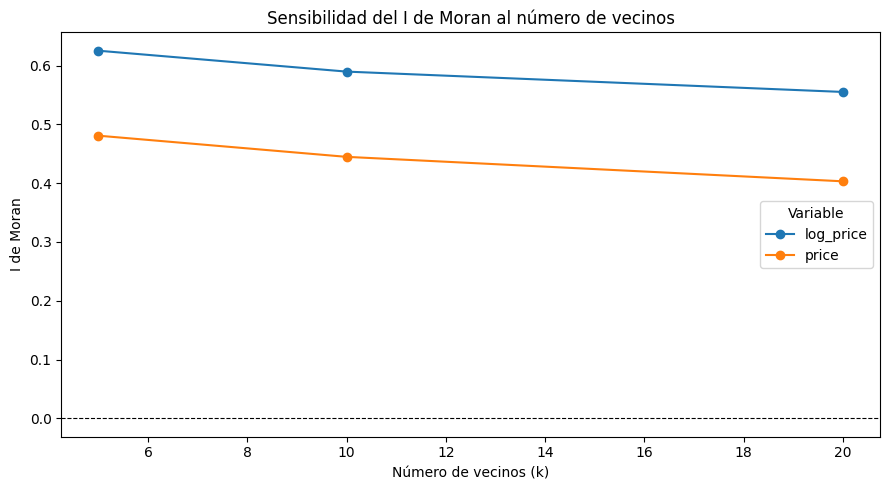

In [672]:
moran_comparison = moran_results.pivot(
    index="Vecinos (k)",
    columns="Variable",
    values="I de Moran",
)

ax = moran_comparison.plot(marker="o", figsize=(9, 5))
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Número de vecinos (k)")
ax.set_ylabel("I de Moran")
ax.set_title("Sensibilidad del I de Moran al número de vecinos")
ax.legend(title="Variable")
plt.tight_layout()
plt.show()

### Gráficos de Moran

Para visualizar el patrón se utiliza la matriz intermedia KNN con 10 vecinos. El eje horizontal muestra el precio estandarizado de cada inmueble y el vertical representa el rezago espacial, es decir, el comportamiento promedio de sus vecinos. Una pendiente positiva refleja agrupación de valores similares.

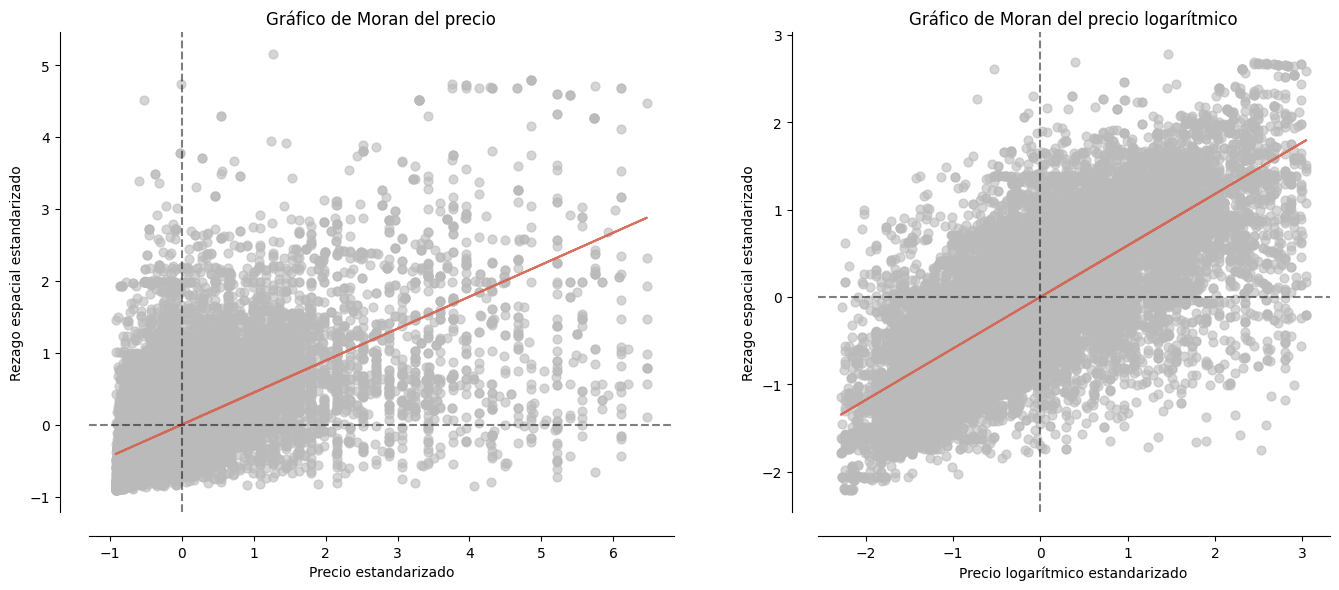

In [673]:
from splot.esda import moran_scatterplot

figure, axes = plt.subplots(1, 2, figsize=(14, 6))

moran_scatterplot(
    moran_statistics[(10, "price")],
    ax=axes[0],
    aspect_equal=True,
)
axes[0].set_title("Gráfico de Moran del precio")
axes[0].set_xlabel("Precio estandarizado")
axes[0].set_ylabel("Rezago espacial estandarizado")

moran_scatterplot(
    moran_statistics[(10, "log_price")],
    ax=axes[1],
    aspect_equal=True,
)
axes[1].set_title("Gráfico de Moran del precio logarítmico")
axes[1].set_xlabel("Precio logarítmico estandarizado")
axes[1].set_ylabel("Rezago espacial estandarizado")

plt.tight_layout()
plt.show()

### Lectura de la autocorrelación global

El precio presenta una autocorrelación espacial positiva, fuerte y estadísticamente significativa en el conjunto de entrenamiento. Para `log_price`, el I de Moran disminuye de 0,6254 con 5 vecinos a 0,5898 con 10 y 0,5553 con 20; en todos los casos `p = 0.001`. El precio original muestra el mismo patrón, aunque con menor intensidad: 0,4808, 0,4448 y 0,4032.

La disminución al aumentar $k$ indica que la semejanza de precios es principalmente local y se diluye al incorporar viviendas más lejanas. La mayor autocorrelación de `log_price` muestra que la transformación reduce la influencia de precios extremos y hace más visible la estructura espacial general. La conclusión es robusta a las tres definiciones de vecindad.

Se adopta KNN con 20 vecinos para los modelos porque mantiene una asociación espacial fuerte y, a diferencia de $k=5$ y $k=10$, genera una única red conectada.

## Autocorrelación espacial de los residuos de Random Forest

El I de Moran del precio confirma que existe un patrón espacial, pero no permite saber si Random Forest ya consiguió explicarlo. Para evaluarlo se calculan los residuos del modelo optimizado sobre el conjunto de prueba. Un residuo positivo indica que el modelo subestimó el precio y uno negativo indica que lo sobreestimó.

La matriz espacial se reconstruye utilizando solamente las observaciones de prueba para evitar relacionarlas con datos empleados durante el entrenamiento.

In [674]:
test_spatial_data = test_set.loc[
    test_target.index,
    ["lat", "lon", "price"],
].copy()
test_spatial_data["random_forest_residual"] = (
    test_target.to_numpy() - y_pred_test_best_random_forest
)

test_gdf = gpd.GeoDataFrame(
    test_spatial_data,
    geometry=gpd.points_from_xy(
        test_spatial_data["lon"],
        test_spatial_data["lat"],
    ),
    crs="EPSG:4326",
).to_crs(epsg=9377)
test_gdf = test_gdf.reset_index(drop=True)

test_weights = KNN.from_dataframe(
    test_gdf,
    k=20,
    use_index=True,
)
test_weights.transform = "R"

print(f"Observaciones de prueba: {len(test_gdf)}")
print(f"Componentes de la matriz KNN: {test_weights.n_components}")

Observaciones de prueba: 10745
Componentes de la matriz KNN: 1


In [675]:
np.random.seed(42)
random_forest_residual_moran = Moran(
    test_gdf["random_forest_residual"].to_numpy(),
    test_weights,
    permutations=999,
)

random_forest_residual_results = pd.DataFrame(
    {
        "Indicador": [
            "I de Moran",
            "I esperado",
            "Valor p simulado",
            "Z simulado",
        ],
        "Resultado": [
            random_forest_residual_moran.I,
            random_forest_residual_moran.EI,
            random_forest_residual_moran.p_sim,
            random_forest_residual_moran.z_sim,
        ],
    }
)
random_forest_residual_results.round(4)

,Indicador,Resultado
0,I de Moran,0.0212
1,I esperado,-0.0001
2,Valor p simulado,0.0010
3,Z simulado,7.5142


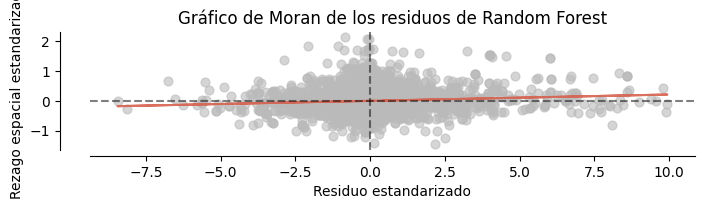

In [676]:
figure, axis = plt.subplots(figsize=(7, 6))
moran_scatterplot(
    random_forest_residual_moran,
    ax=axis,
    aspect_equal=True,
)
axis.set_title("Gráfico de Moran de los residuos de Random Forest")
axis.set_xlabel("Residuo estandarizado")
axis.set_ylabel("Rezago espacial estandarizado")
plt.tight_layout()
plt.show()

### Interpretación de los residuos de Random Forest

En las 10.745 observaciones de prueba, los residuos en la escala original presentan un I de Moran de 0,0212 con `p = 0.001`. La asociación es detectable por el tamaño de la muestra, pero su magnitud es muy baja. Random Forest deja, por tanto, una agrupación espacial residual leve y captura la mayor parte de la estructura asociada con ubicación, barrio y relaciones no lineales. Este resultado se usa solo como referencia predictiva; el análisis central de la dependencia espacial corresponde a OLS, SEM y SAR-Lag.

## Regresión OLS hedónica para diagnóstico espacial

OLS se ajusta exclusivamente con entrenamiento y sirve como modelo global de referencia para aplicar los diagnósticos que orientan la elección entre SAR-Lag y SEM. Se usan habitaciones, dormitorios, baños, tipo de propiedad y barrio. Las transformaciones también se aprenden únicamente con entrenamiento.

In [677]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

ols_numeric_features = ["rooms", "bedrooms", "bathrooms"]
ols_categorical_features = ["neighborhood", "property_type"]
ols_features = ols_numeric_features + ols_categorical_features

ols_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            ols_numeric_features,
        ),
        (
            "categorical",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)),
            ]),
            ols_categorical_features,
        ),
    ]
)

train_spatial_x = ols_preprocessor.fit_transform(train_gdf[ols_features]).astype(float)
train_spatial_y = train_gdf["log_price"].to_numpy().reshape(-1, 1)
spatial_feature_names = ols_preprocessor.get_feature_names_out().tolist()

print(f"Observaciones de entrenamiento: {train_spatial_x.shape[0]}")
print(f"Variables explicativas después de la codificación: {train_spatial_x.shape[1]}")

Observaciones de entrenamiento: 25069
Variables explicativas después de la codificación: 30


In [678]:
from spreg import OLS

ols_spatial_model = OLS(
    train_spatial_y,
    train_spatial_x,
    w=train_spatial_weights[20],
    spat_diag=True,
    moran=True,
    name_y="Precio logarítmico",
    name_x=spatial_feature_names,
    name_w="KNN de entrenamiento con 20 vecinos",
    name_ds="Viviendas de Medellín - entrenamiento",
)

print(ols_spatial_model.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES
------------------------------------------------------------------------------------
Data set            :Viviendas de Medellín - entrenamiento
Weights matrix      :KNN de entrenamiento con 20 vecinos
Dependent Variable  :Precio logarítmico                Number of Observations:       25069
Mean dependent var  :     19.9086                Number of Variables   :          31
S.D. dependent var  :      0.7384                Degrees of Freedom    :       25038
R-squared           :      0.5870
Adjusted R-squared  :      0.5865
Sum squared residual:     5645.08                F-statistic           :   1186.3434
Sigma-square        :       0.225                Prob(F-statistic)     :           0
S.E. of regression  :       0.475                Log likelihood        :  -16884.339
Sigma-square ML     :       0.225                Akaike info criterion :   33830.678
S.E of regression ML:      0.4745                

### Diagnósticos espaciales del modelo OLS

El I de Moran de los residuos permite verificar si el OLS deja estructura espacial sin explicar. Las pruebas LM evalúan dos alternativas: LM-Lag busca dependencia en la variable dependiente y LM-Error busca dependencia en el término de error. Cuando ambas pruebas son significativas, sus versiones robustas ayudan a identificar el proceso dominante.

In [679]:
np.random.seed(42)
ols_residual_moran = Moran(
    ols_spatial_model.u.flatten(),
    train_spatial_weights[20],
    permutations=999,
)

ols_spatial_diagnostics = pd.DataFrame(
    [
        {
            "Diagnóstico": "I de Moran de los residuos",
            "Estadístico": ols_residual_moran.I,
            "Valor p": ols_residual_moran.p_sim,
        },
        {
            "Diagnóstico": "LM-Lag",
            "Estadístico": ols_spatial_model.lm_lag[0],
            "Valor p": ols_spatial_model.lm_lag[1],
        },
        {
            "Diagnóstico": "LM-Error",
            "Estadístico": ols_spatial_model.lm_error[0],
            "Valor p": ols_spatial_model.lm_error[1],
        },
        {
            "Diagnóstico": "LM-Lag robusto",
            "Estadístico": ols_spatial_model.rlm_lag[0],
            "Valor p": ols_spatial_model.rlm_lag[1],
        },
        {
            "Diagnóstico": "LM-Error robusto",
            "Estadístico": ols_spatial_model.rlm_error[0],
            "Valor p": ols_spatial_model.rlm_error[1],
        },
    ]
)
def format_analytical_p_value(value):
    return "< 0.001" if value < 0.001 else f"{value:.3f}"


ols_spatial_diagnostics_display = ols_spatial_diagnostics.copy()
ols_spatial_diagnostics_display["Valor p"] = (
    ols_spatial_diagnostics_display["Valor p"].map(format_analytical_p_value)
)
ols_spatial_diagnostics_display["Estadístico"] = (
    ols_spatial_diagnostics_display["Estadístico"].round(4)
)
ols_spatial_diagnostics_display

,Diagnóstico,Estadístico,Valor p
0,I de Moran de los residuos,0.2461,0.001
1,LM-Lag,13324.0339,< 0.001
2,LM-Error,18005.3833,< 0.001
3,LM-Lag robusto,1265.3581,< 0.001
4,LM-Error robusto,5946.7075,< 0.001


In [680]:
ols_model_metrics = pd.DataFrame(
    {
        "Métrica": ["R²", "R² ajustado", "AIC", "RMSE en escala logarítmica"],
        "Resultado": [
            ols_spatial_model.r2,
            ols_spatial_model.ar2,
            ols_spatial_model.aic,
            np.sqrt(
                mean_squared_error(
                    train_spatial_y.flatten(),
                    ols_spatial_model.predy.flatten(),
                )
            ),
        ],
    }
)
ols_model_metrics.round(4)

,Métrica,Resultado
0,R²,0.5870
1,R² ajustado,0.5865
2,AIC,33830.6779
3,RMSE en escala logarítmica,0.4745


### Interpretación del diagnóstico OLS en entrenamiento

OLS obtiene R² = 0,5870 y RMSE = 0,4745 en `log_price`, pero sus residuos conservan una autocorrelación espacial considerable: I de Moran = 0,2461 con `p = 0.001`. Por tanto, aun después de controlar habitaciones, dormitorios, baños, barrio y tipo de propiedad, permanecen patrones geográficos sin explicar.

LM-Lag y LM-Error son significativos, al igual que sus versiones robustas. LM-Error robusto (5.946,71) es claramente mayor que LM-Lag robusto (1.265,36), lo que aporta más evidencia a favor de dependencia en factores omitidos espacialmente correlacionados. Sin embargo, la significancia de ambas pruebas justifica estimar tanto SEM como SAR-Lag.

Los residuos tampoco cumplen normalidad ni homocedasticidad: Jarque-Bera, Breusch-Pagan y Koenker-Bassett tienen `p < 0.001`. OLS funciona como referencia, pero sus supuestos estadísticos y espaciales no describen adecuadamente los datos.

## Modelos de dependencia espacial

Las pruebas LM robustas fueron significativas tanto para dependencia en el error como para dependencia en la variable dependiente. Por esta razón se ajustan los dos modelos y se comparan empíricamente.

- **SEM:** representa la dependencia espacial mediante el término de error. Su parámetro λ indica la intensidad con la que factores espaciales no observados se relacionan entre viviendas vecinas.
- **SAR-Lag:** incorpora el rezago espacial de `log_price`. Su parámetro ρ representa la relación entre el precio de una vivienda y los precios de sus vecinas, después de controlar las características incluidas.

Se utilizan las implementaciones `GM_Error_Het` y `GM_Lag` presentadas en el capítulo de modelos SAR del libro. Estos estimadores GMM son apropiados para una muestra grande y el primero permite errores heterocedásticos.

### Modelo de error espacial (SEM)

In [681]:
import spreg

sem_model = spreg.GM_Error_Het(
    train_spatial_y,
    train_spatial_x,
    w=train_spatial_weights[20],
    name_y="Precio logarítmico",
    name_x=spatial_feature_names,
    name_w="KNN de entrenamiento con 20 vecinos",
    name_ds="Viviendas de Medellín - entrenamiento",
)

print(sem_model.summary)

GM_Error_Het
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: GM SPATIALLY WEIGHTED LEAST SQUARES (HET)
------------------------------------------------------------------------------------
Data set            :Viviendas de Medellín - entrenamiento
Weights matrix      :KNN de entrenamiento con 20 vecinos
Dependent Variable  :Precio logarítmico                Number of Observations:       25069
Mean dependent var  :     19.9086                Number of Variables   :          31
S.D. dependent var  :      0.7384                Degrees of Freedom    :       25038
Pseudo R-squared    :      0.5773
N. of iterations    :           1                Step1c computed       :          No

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
------------------------------------------------------------------------------------
            CONSTANT        19.72307         0.043

### Modelo de rezago espacial (SAR-Lag)

In [682]:
sar_lag_model = spreg.GM_Lag(
    train_spatial_y,
    train_spatial_x,
    w=train_spatial_weights[20],
    name_y="Precio logarítmico",
    name_x=spatial_feature_names,
    name_w="KNN de entrenamiento con 20 vecinos",
    name_ds="Viviendas de Medellín - entrenamiento",
)

print(sar_lag_model.summary)

GM_Lag
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: SPATIAL TWO STAGE LEAST SQUARES
------------------------------------------------------------------------------------
Data set            :Viviendas de Medellín - entrenamiento
Weights matrix      :KNN de entrenamiento con 20 vecinos
Dependent Variable  :Precio logarítmico                Number of Observations:       25069
Mean dependent var  :     19.9086                Number of Variables   :          32
S.D. dependent var  :      0.7384                Degrees of Freedom    :       25037
Pseudo R-squared    :      0.6749
Spatial Pseudo R-squared:  0.6045

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
------------------------------------------------------------------------------------
            CONSTANT         8.89583         0.22133        40.19208         0.00000
      numeric__rooms         0.0

### Autocorrelación residual de los modelos espaciales en entrenamiento

Estos diagnósticos describen el ajuste sin utilizar prueba. En SEM se analiza `e_filtered`; en SAR-Lag se utiliza `u`. Un modelo espacial adecuado debería reducir el I de Moran residual respecto a OLS.

In [683]:
np.random.seed(42)
sem_residual_moran = Moran(
    sem_model.e_filtered.flatten(),
    train_spatial_weights[20],
    permutations=999,
)
sar_lag_residual_moran = Moran(
    sar_lag_model.u.flatten(),
    train_spatial_weights[20],
    permutations=999,
)

spatial_residual_results = pd.DataFrame(
    {
        "Modelo": ["OLS", "SEM", "SAR-Lag"],
        "Residuo evaluado": ["u", "e_filtered", "u"],
        "I de Moran residual": [
            ols_residual_moran.I,
            sem_residual_moran.I,
            sar_lag_residual_moran.I,
        ],
        "Valor p simulado": [
            ols_residual_moran.p_sim,
            sem_residual_moran.p_sim,
            sar_lag_residual_moran.p_sim,
        ],
    }
)
spatial_residual_results.round(4)

,Modelo,Residuo evaluado,I de Moran residual,Valor p simulado
0,OLS,u,0.2461,0.001
1,SEM,e_filtered,-0.0013,0.243
2,SAR-Lag,u,0.0353,0.001


### Interpretación de SEM y SAR-Lag durante el ajuste

SEM estima $\lambda=0,7351$ con `p < 0.001`, evidencia de una dependencia fuerte entre factores no observados de viviendas cercanas. Después de filtrar ese componente, el residuo presenta I de Moran = -0,0013 con `p = 0.243`. No se rechaza la aleatoriedad espacial: SEM es el modelo que representa mejor la dependencia de los errores durante el ajuste.

SAR-Lag estima $\rho=0,5496$ con `p < 0.001`. Esto indica una asociación positiva importante entre el precio logarítmico de una vivienda y el promedio de precios de sus vecinas, controlando las características incluidas. Su pseudo-R² es 0,6749, superior al ajuste de OLS y SEM. No obstante, sus residuos aún presentan autocorrelación baja pero significativa (I = 0,0353; `p = 0.001`), corroborada por la prueba de Anselin-Kelejian.

Los impactos de SAR-Lag muestran además efectos de desbordamiento. Para baños, el efecto directo es 0,2517, el indirecto 0,3071 y el total 0,5588 en escala logarítmica por una desviación estándar de la variable. En consecuencia, SEM es superior para modelar el error espacial, mientras SAR-Lag ofrece mejor ajuste y permite interpretar retroalimentación entre precios vecinos.

## Comparación de todos los modelos en el conjunto de prueba

Todos los modelos ya fueron ajustados una sola vez y exclusivamente con entrenamiento. En esta sección solo se transforma prueba con el preprocesador aprendido, se generan predicciones y se comparan OLS, SEM, SAR-Lag, Random Forest y XGBoost sobre las mismas observaciones y la misma variable objetivo, `log_price`.

### Preparación espacial del conjunto de prueba

El preprocesador ajustado con entrenamiento se aplica mediante `transform`. La matriz KNN de prueba se construye solo con sus ubicaciones y se utiliza para la predicción reducida de SAR-Lag y para el I de Moran de los residuos; en ningún caso se usan los precios reales para ajustar parámetros.

In [684]:
test_spatial_x = ols_preprocessor.transform(test_set[ols_features]).astype(float)
test_spatial_y = np.log(test_set["price"].to_numpy())

test_spatial_gdf = gpd.GeoDataFrame(
    test_set.copy(),
    geometry=gpd.points_from_xy(test_set["lon"], test_set["lat"]),
    crs="EPSG:4326",
).to_crs(epsg=9377).reset_index(drop=True)

test_spatial_weights = KNN.from_dataframe(
    test_spatial_gdf,
    k=20,
    use_index=True,
)
test_spatial_weights.transform = "R"

print(f"Observaciones de prueba: {len(test_spatial_gdf)}")
print(f"Componentes KNN de prueba: {test_spatial_weights.n_components}")

Observaciones de prueba: 10745
Componentes KNN de prueba: 1


### Verificación del protocolo

Los objetos `ols_spatial_model`, `sem_model` y `sar_lag_model` provienen del ajuste anterior sobre `train_spatial_x` y `train_spatial_y`. No se vuelven a estimar aquí.

In [685]:
training_protocol = pd.DataFrame(
    {
        "Modelo": ["OLS", "SEM", "SAR-Lag", "Random Forest", "XGBoost"],
        "Ajuste": ["Entrenamiento"] * 5,
        "Evaluación final": ["Prueba"] * 5,
    }
)
training_protocol

,Modelo,Ajuste,Evaluación final
0,OLS,Entrenamiento,Prueba
1,SEM,Entrenamiento,Prueba
2,SAR-Lag,Entrenamiento,Prueba
3,Random Forest,Entrenamiento,Prueba
4,XGBoost,Entrenamiento,Prueba


### Predicción sobre el conjunto de prueba

OLS y SEM predicen la parte sistemática $X\beta$. En SEM, el componente espacial pertenece al error y no puede predecirse en una ubicación nueva sin observar errores cercanos.

SAR-Lag se predice mediante su forma reducida:

$$
\hat y=(I-\hat\rho W_{test})^{-1}X_{test}\hat\beta
$$

Esta expresión incorpora la retroalimentación espacial entre las ubicaciones de prueba, pero no utiliza sus precios reales.

In [686]:
from scipy.sparse import identity
from scipy.sparse.linalg import spsolve

test_spatial_x_constant = np.column_stack(
    [np.ones(test_spatial_x.shape[0]), test_spatial_x]
)

ols_test_log_prediction = test_spatial_x_constant @ ols_spatial_model.betas.flatten()
sem_test_log_prediction = test_spatial_x_constant @ sem_model.betas[:-1].flatten()

sar_lag_rho = sar_lag_model.betas[-1, 0]
sar_lag_linear_prediction = test_spatial_x_constant @ sar_lag_model.betas[:-1].flatten()
sar_lag_test_log_prediction = spsolve(
    identity(len(test_spatial_y), format="csr")
    - sar_lag_rho * test_spatial_weights.sparse,
    sar_lag_linear_prediction,
)

random_forest_test_log_prediction = np.log(
    np.clip(y_pred_test_best_random_forest, a_min=1, a_max=None)
)
xgboost_test_log_prediction = np.log(
    np.clip(y_pred_test_best_xgboost, a_min=1, a_max=None)
)

test_log_predictions = {
    "OLS": ols_test_log_prediction,
    "SEM": sem_test_log_prediction,
    "SAR-Lag": sar_lag_test_log_prediction,
    "Random Forest": random_forest_test_log_prediction,
    "XGBoost": xgboost_test_log_prediction,
}

### Métricas comparables en prueba

Todos los modelos se evalúan con R², MAE y RMSE sobre `log_price`. También se calcula el I de Moran de sus residuos usando la misma matriz KNN de prueba. En esta tabla, una diferencia de desempeño corresponde al modelo y no a una muestra de evaluación diferente.

In [687]:
np.random.seed(42)
test_comparison_rows = []
test_residual_moran = {}

for model_name, prediction in test_log_predictions.items():
    residual = test_spatial_y - prediction
    moran = Moran(
        residual,
        test_spatial_weights,
        permutations=999,
    )
    test_residual_moran[model_name] = moran
    test_comparison_rows.append(
        {
            "Modelo": model_name,
            "R² log_price": r2_score(test_spatial_y, prediction),
            "MAE log_price": mean_absolute_error(test_spatial_y, prediction),
            "RMSE log_price": np.sqrt(
                mean_squared_error(test_spatial_y, prediction)
            ),
            "I de Moran residual": moran.I,
            "Valor p de Moran": moran.p_sim,
        }
    )

test_model_comparison = pd.DataFrame(test_comparison_rows)
test_model_comparison_display = test_model_comparison.copy()
test_model_comparison_display["Valor p de Moran"] = (
    test_model_comparison_display["Valor p de Moran"].map(
        lambda value: f"{value:.3f}"
    )
)
test_model_comparison_display.round(4)

,Modelo,R² log_price,MAE log_price,RMSE log_price,I de Moran residual,Valor p de Moran
0,OLS,0.5828,0.3560,0.4752,0.1926,0.001
1,SEM,0.5649,0.3675,0.4853,0.2437,0.001
2,SAR-Lag,0.5997,0.3491,0.4655,0.1753,0.001
3,Random Forest,0.7756,0.2226,0.3485,0.0293,0.001
4,XGBoost,0.5944,0.3232,0.4686,0.0790,0.001


## Visualización de la comparación en prueba

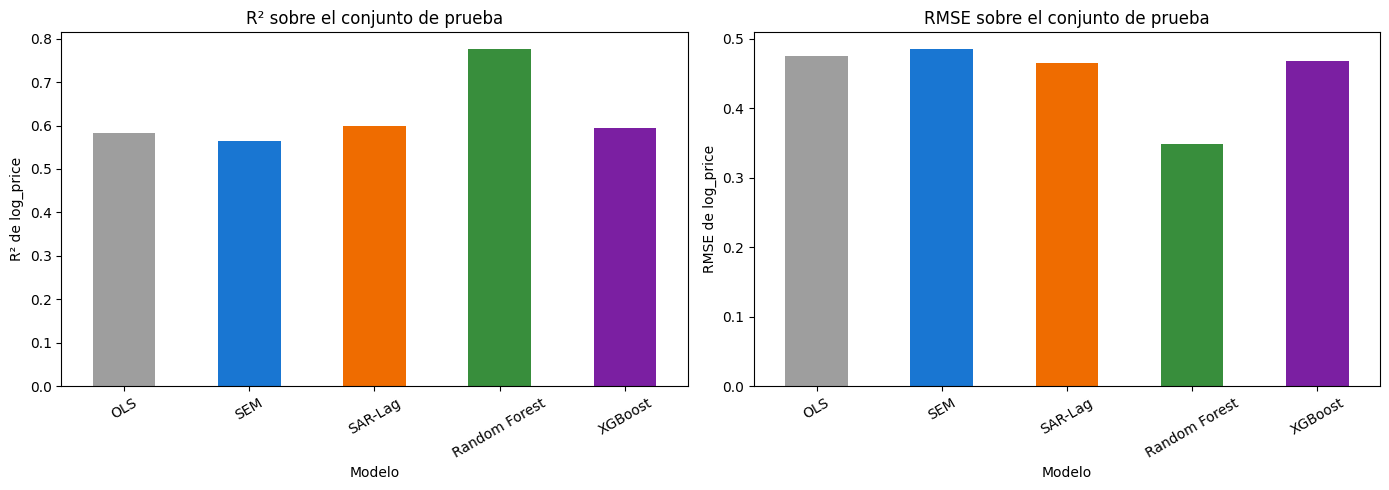

In [688]:
figure, axes = plt.subplots(1, 2, figsize=(14, 5))

test_model_comparison.plot.bar(
    x="Modelo",
    y="R² log_price",
    color=["#9E9E9E", "#1976D2", "#EF6C00", "#388E3C", "#7B1FA2"],
    legend=False,
    ax=axes[0],
)
axes[0].set_title("R² sobre el conjunto de prueba")
axes[0].set_xlabel("Modelo")
axes[0].set_ylabel("R² de log_price")
axes[0].tick_params(axis="x", rotation=30)

test_model_comparison.plot.bar(
    x="Modelo",
    y="RMSE log_price",
    color=["#9E9E9E", "#1976D2", "#EF6C00", "#388E3C", "#7B1FA2"],
    legend=False,
    ax=axes[1],
)
axes[1].set_title("RMSE sobre el conjunto de prueba")
axes[1].set_xlabel("Modelo")
axes[1].set_ylabel("RMSE de log_price")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

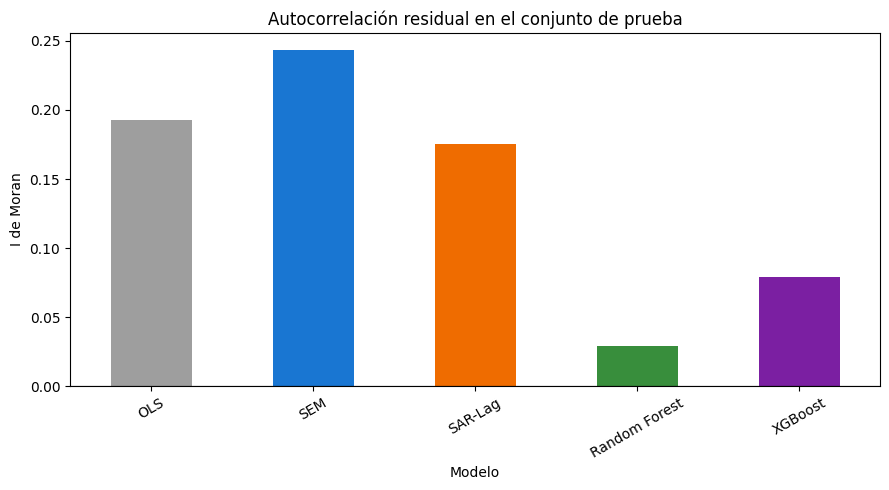

In [689]:
figure, axis = plt.subplots(figsize=(9, 5))
test_model_comparison.plot.bar(
    x="Modelo",
    y="I de Moran residual",
    color=["#9E9E9E", "#1976D2", "#EF6C00", "#388E3C", "#7B1FA2"],
    legend=False,
    ax=axis,
)
axis.axhline(0, color="black", linewidth=0.8)
axis.set_title("Autocorrelación residual en el conjunto de prueba")
axis.set_xlabel("Modelo")
axis.set_ylabel("I de Moran")
axis.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

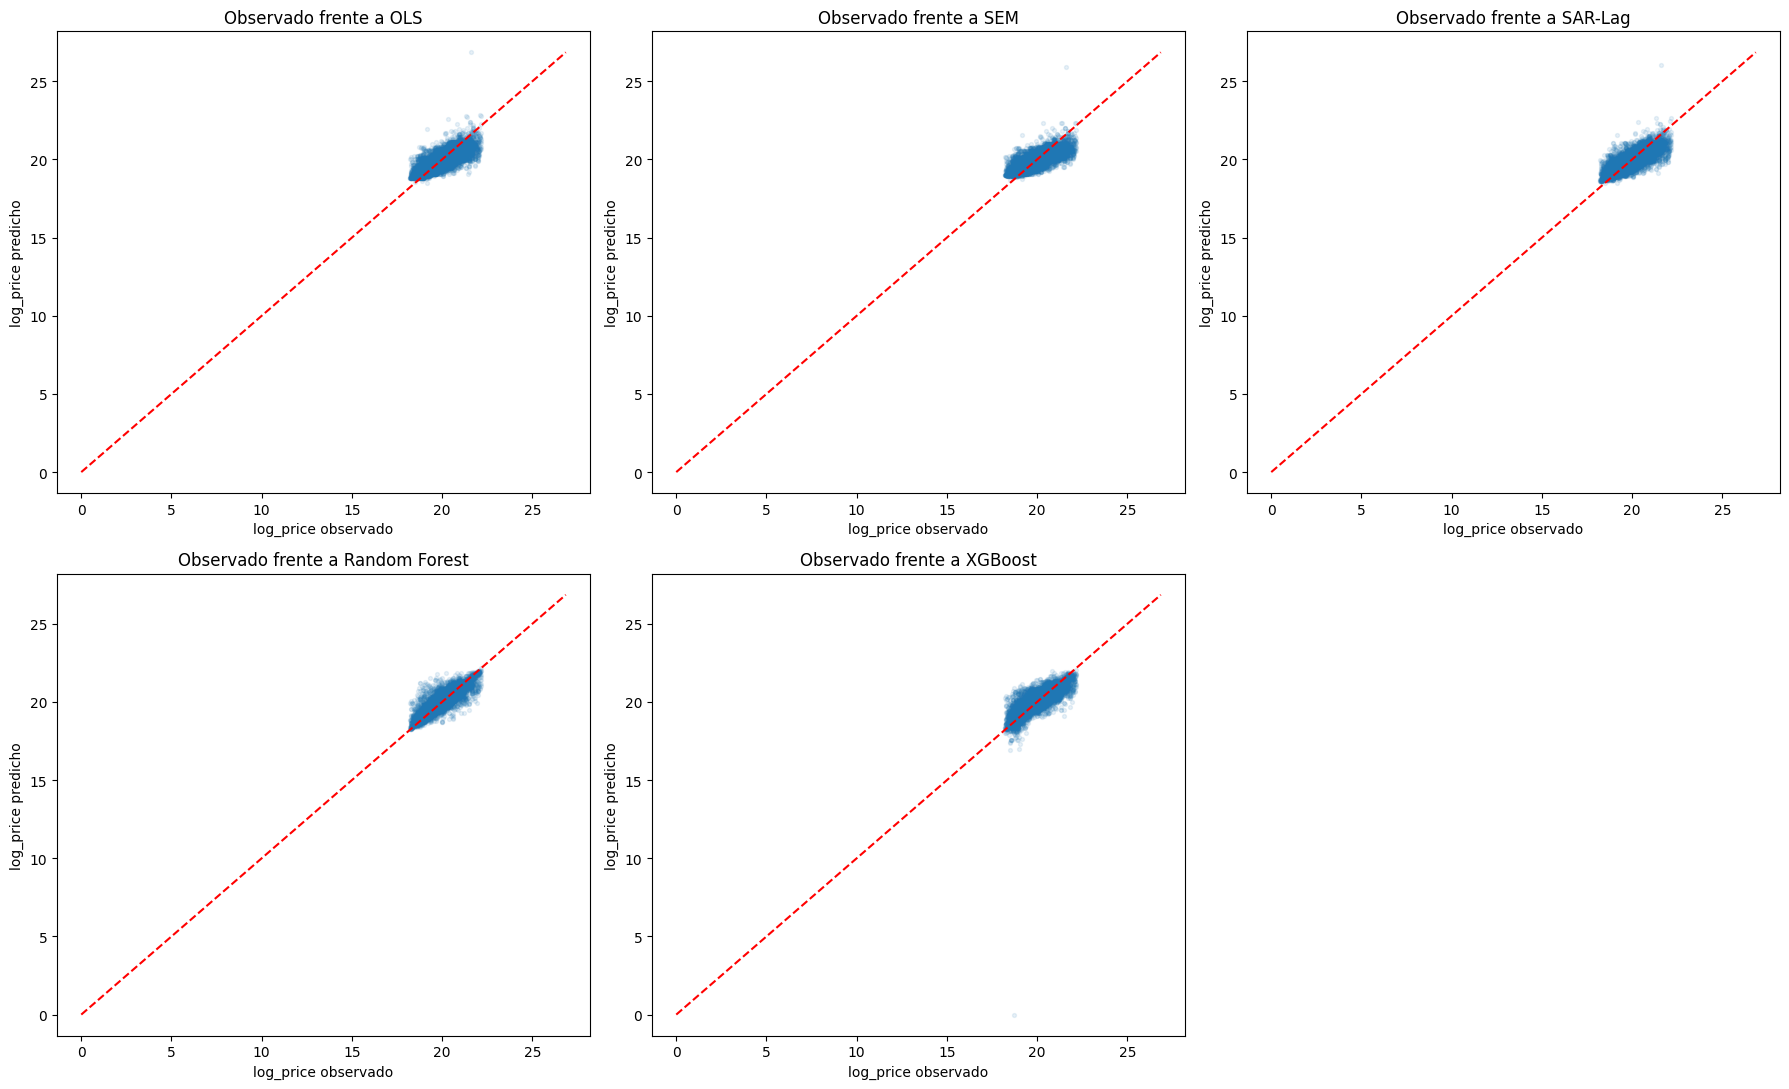

In [690]:
figure, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()
plot_minimum = min(
    test_spatial_y.min(),
    *(prediction.min() for prediction in test_log_predictions.values()),
)
plot_maximum = max(
    test_spatial_y.max(),
    *(prediction.max() for prediction in test_log_predictions.values()),
)

for axis, (model_name, prediction) in zip(axes, test_log_predictions.items()):
    axis.scatter(test_spatial_y, prediction, alpha=0.10, s=8)
    axis.plot(
        [plot_minimum, plot_maximum],
        [plot_minimum, plot_maximum],
        color="red",
        linestyle="--",
    )
    axis.set_title(f"Observado frente a {model_name}")
    axis.set_xlabel("log_price observado")
    axis.set_ylabel("log_price predicho")

axes[-1].axis("off")
plt.tight_layout()
plt.show()

## Interpretación de la comparación en prueba

La evaluación fuera de muestra confirma que SAR-Lag es el mejor modelo estadístico espacial para predicción: alcanza R² = 0,5997, MAE = 0,3491 y RMSE = 0,4655 en `log_price`. Supera a OLS (R² = 0,5828; RMSE = 0,4752) y SEM (R² = 0,5649; RMSE = 0,4853). También reduce el I de Moran residual a 0,1753 frente a 0,1926 de OLS, aunque todavía queda dependencia significativa.

SEM deja un I de Moran de 0,2437 en prueba. Esto no contradice su excelente diagnóstico durante el ajuste: SEM filtra la dependencia de errores observados, pero para ubicaciones nuevas se predice solo $X\hat\beta$, porque no se conocen los errores vecinos. Por eso su fortaleza es explicar y corregir la estructura del error, no necesariamente maximizar la predicción fuera de muestra.

Como referencia, Random Forest conserva el mejor desempeño general (R² = 0,7756; RMSE = 0,3485) y la menor autocorrelación residual (I = 0,0293). XGBoost obtiene R² = 0,5944 y RMSE = 0,4686, muy próximo a SAR-Lag en predicción, pero deja menor dependencia residual (I = 0,0790). La elección depende del objetivo: Random Forest para precisión predictiva, SAR-Lag para predicción espacial interpretable y SEM para representar factores omitidos espacialmente correlacionados.

# Heterogeneidad espacial

Los modelos OLS, SEM y SAR-Lag anteriores suponen relaciones constantes en toda Medellín. Esta sección estudia si la asociación entre las características de la vivienda y `log_price` cambia según la ubicación. Se implementan **GWR**, con un único ancho de banda para todos los términos, y **MGWR**, que permite una escala espacial diferente para cada variable.

El análisis es explicativo, utiliza únicamente entrenamiento y se añade sin reemplazar los modelos anteriores.

In [ ]:
%pip install mgwr

## Muestra con cobertura espacial

GWR y MGWR ajustan regresiones locales repetidamente y su costo crece con rapidez. Para hacer viable y reproducible el análisis se seleccionan hasta 20 viviendas en cada celda formada por deciles de latitud y longitud. Antes se excluyen coordenadas fuera del entorno de Medellín. Esta muestra de máximo 2.000 puntos se usa exclusivamente en esta sección.

In [ ]:
heterogeneity_candidates = train_gdf.loc[
    train_gdf["lat"].between(6.0, 6.5)
    & train_gdf["lon"].between(-75.8, -75.4)
].copy()
heterogeneity_candidates["training_position"] = heterogeneity_candidates.index
heterogeneity_candidates["latitude_group"] = pd.qcut(
    heterogeneity_candidates["lat"], q=10, labels=False, duplicates="drop"
)
heterogeneity_candidates["longitude_group"] = pd.qcut(
    heterogeneity_candidates["lon"], q=10, labels=False, duplicates="drop"
)

random_generator = np.random.default_rng(42)
selected_indices = []
for _, spatial_group in heterogeneity_candidates.groupby(
    ["latitude_group", "longitude_group"], observed=True
):
    group_indices = spatial_group.index.to_numpy()
    selected_indices.extend(
        random_generator.choice(
            group_indices, size=min(20, len(group_indices)), replace=False
        )
    )

heterogeneity_gdf = (
    heterogeneity_candidates.loc[selected_indices].sort_index().reset_index(drop=True)
)
print(f"Observaciones válidas en Medellín: {len(heterogeneity_candidates)}")
print(f"Observaciones seleccionadas: {len(heterogeneity_gdf)}")

## Variables y coordenadas

Se conserva `log_price` como respuesta y se usan habitaciones, dormitorios y baños. Los predictores provienen del preprocesamiento ya ajustado con entrenamiento: imputación por mediana y estandarización. No se incluyen indicadores categóricos porque una gran cantidad de coeficientes locales puede generar inestabilidad y dificultar su interpretación. Las coordenadas proyectadas en `EPSG:9377` permiten calcular distancias en metros.

In [ ]:
heterogeneity_positions = heterogeneity_gdf["training_position"].to_numpy(dtype=int)
heterogeneity_feature_names = ["Habitaciones", "Dormitorios", "Baños"]
heterogeneity_x = train_spatial_x[heterogeneity_positions, :3].astype(float)
heterogeneity_y = train_spatial_y[heterogeneity_positions].astype(float)
heterogeneity_coordinates = np.column_stack(
    [heterogeneity_gdf.geometry.x, heterogeneity_gdf.geometry.y]
).astype(float)
print(f"Forma de X: {heterogeneity_x.shape}; forma de y: {heterogeneity_y.shape}")

## Regresión Geográficamente Ponderada (GWR)

GWR estima coeficientes alrededor de cada vivienda. Se utiliza un kernel bisquare adaptativo, adecuado para densidades irregulares de puntos. El ancho de banda, expresado como número de vecinos, se selecciona minimizando el AICc.

In [ ]:
from mgwr.gwr import GWR, MGWR
from mgwr.sel_bw import Sel_BW

gwr_selector = Sel_BW(
    heterogeneity_coordinates, heterogeneity_y, heterogeneity_x,
    fixed=False, kernel="bisquare", spherical=False, n_jobs=-1,
)
gwr_bandwidth = gwr_selector.search(criterion="AICc")
gwr_model = GWR(
    heterogeneity_coordinates, heterogeneity_y, heterogeneity_x,
    bw=gwr_bandwidth, fixed=False, kernel="bisquare",
    spherical=False, hat_matrix=True, n_jobs=-1,
)
gwr_results = gwr_model.fit()
print(f"Ancho de banda GWR: {int(gwr_bandwidth)} vecinos")
print(gwr_results.summary())

## Regresión Geográficamente Ponderada Multiescala (MGWR)

MGWR asigna un ancho de banda al intercepto y a cada predictor. Un ancho pequeño representa un proceso local; uno cercano al tamaño de la muestra indica una relación más estable o global. La estimación usa *backfitting* multiescala.

In [ ]:
mgwr_selector = Sel_BW(
    heterogeneity_coordinates, heterogeneity_y, heterogeneity_x,
    multi=True, fixed=False, kernel="bisquare", spherical=False, n_jobs=-1,
)
mgwr_bandwidths = mgwr_selector.search(
    criterion="AICc", init_multi=gwr_bandwidth, multi_bw_min=[40],
    tol_multi=1e-4, max_iter_multi=50,
)
mgwr_model = MGWR(
    heterogeneity_coordinates, heterogeneity_y, heterogeneity_x,
    selector=mgwr_selector, fixed=False, kernel="bisquare",
    spherical=False, hat_matrix=True, n_jobs=-1,
)
mgwr_results = mgwr_model.fit()
mgwr_bandwidth_table = pd.DataFrame({
    "Término": ["Intercepto"] + heterogeneity_feature_names,
    "Ancho de banda (vecinos)": np.asarray(mgwr_bandwidths, dtype=int),
})
display(mgwr_bandwidth_table)
print(mgwr_results.summary())

## Comparación y diagnóstico de heterogeneidad

La comparación se hace con la misma muestra y especificación. Un AICc menor indica mejor equilibrio entre ajuste y complejidad. La dispersión de coeficientes y los anchos de banda permiten determinar si las asociaciones cambian en el espacio. Estas métricas describen ajuste en la muestra, no predicción fuera de muestra.

In [ ]:
from spreg import OLS as SpatialOLS

heterogeneity_ols = SpatialOLS(heterogeneity_y, heterogeneity_x)
heterogeneity_model_comparison = pd.DataFrame({
    "Modelo": ["OLS global", "GWR", "MGWR"],
    "R²": [heterogeneity_ols.r2, gwr_results.R2, mgwr_results.R2],
    "R² ajustado": [heterogeneity_ols.ar2, gwr_results.adj_R2, mgwr_results.adj_R2],
    "AICc": [np.nan, gwr_results.aicc, mgwr_results.aicc],
    "Parámetros efectivos": [
        heterogeneity_x.shape[1] + 1, gwr_results.ENP, mgwr_results.ENP
    ],
})
display(heterogeneity_model_comparison.round(4))

local_term_names = ["Intercepto"] + heterogeneity_feature_names
local_coefficient_rows = []
for model_name, result in [("GWR", gwr_results), ("MGWR", mgwr_results)]:
    for term_index, term_name in enumerate(local_term_names):
        local_values = result.params[:, term_index]
        local_coefficient_rows.append({
            "Modelo": model_name, "Término": term_name,
            "Mínimo": np.min(local_values),
            "Percentil 25": np.quantile(local_values, 0.25),
            "Mediana": np.median(local_values),
            "Percentil 75": np.quantile(local_values, 0.75),
            "Máximo": np.max(local_values),
            "Rango intercuartílico": (
                np.quantile(local_values, 0.75) - np.quantile(local_values, 0.25)
            ),
        })
local_coefficient_summary = pd.DataFrame(local_coefficient_rows)
local_coefficient_summary.round(4)

## Mapas de resultados MGWR

Los mapas muestran la capacidad explicativa local y los coeficientes de los predictores. Un coeficiente positivo representa una asociación local positiva con `log_price`, manteniendo constantes los demás predictores. Como las variables están estandarizadas, la magnitud corresponde al cambio asociado con una desviación estándar.

In [ ]:
heterogeneity_results_gdf = heterogeneity_gdf.copy()
heterogeneity_results_gdf["R² local"] = mgwr_results.localR2.flatten()
for term_index, term_name in enumerate(local_term_names):
    heterogeneity_results_gdf[f"Coeficiente {term_name}"] = (
        mgwr_results.params[:, term_index]
    )

figure, axes = plt.subplots(2, 2, figsize=(16, 13))
map_columns = [
    "R² local", "Coeficiente Habitaciones",
    "Coeficiente Dormitorios", "Coeficiente Baños",
]
map_titles = [
    "Capacidad explicativa local de MGWR",
    "Efecto local de las habitaciones",
    "Efecto local de los dormitorios",
    "Efecto local de los baños",
]
for axis, column_name, title in zip(axes.flatten(), map_columns, map_titles):
    color_map = "viridis" if column_name == "R² local" else "coolwarm"
    heterogeneity_results_gdf.plot(
        column=column_name, cmap=color_map, markersize=14,
        alpha=0.8, legend=True, ax=axis,
    )
    axis.set_title(title)
    axis.set_axis_off()
plt.tight_layout()
plt.show()

## Criterios de interpretación

La evidencia de heterogeneidad debe leerse conjuntamente: (1) mejora del AICc y R² ajustado; (2) anchos MGWR distintos entre variables; (3) rangos intercuartílicos sustantivos en los coeficientes; y (4) superficies cartográficas coherentes, no solo extremos aislados. Un ancho pequeño indica variación local y uno cercano al tamaño de la muestra sugiere una relación casi global.

Los resultados representan asociaciones, no efectos causales. La submuestra y la ausencia de área, seguridad, accesibilidad y equipamientos limitan su alcance. Como desarrollo posterior se recomienda validación espacial por bloques y pruebas de variabilidad espacial de los coeficientes.